# **Part 1:** Business Understanding (15%)

### **1.1 Problem Restatement (in your own words)**

What is the business problem? Who are the stakeholders? What decision will your model inform — and what decision is the business currently making without a model?



Heritage Credit Union is trying to reduce its 12% loan default rate, which is very much above the industry average and is creating significant financial losses. At the same time, it has to avoid being overly strict and denying good borrowers since that hurts both revenue and its mission of serving the community. The main challenge is essentially finding the right balance between both minimizing defaults and maintaining fair access to credit.

Key stakeholders include the Chief Lending Officer and loan underwriters, who are responsible for improving lending decisions and will directly use the model. The Board of Directors and NCUA regulators care about financial stability, compliance, and fairness in lending practices. Members (borrowers) are also stakeholders since they expect fair and transparent access to loans.

The model is meant to give us a clearer picture of how risky a loan applicant might be, so we can decide whether to approve the loan, take a closer look, or adjust terms like the interest rate. Right now, those decisions rely mostly on fixed rules and human judgment, without really using patterns from past data. Because of that, decisions can be inconsistent, and we might miss some high-risk applicants while also turning away people who are actually good candidates.

### **1.2 Cost Analysis**

Using the costs from scenario.md, compute the FN:FP cost ratio. Which error is more expensive? By how much? Then reason through:

Which evaluation metric fits this cost structure? (accuracy, precision, recall, F1, F2, Average Precision, or something else — pick one and justify)
Will the default 0.5 threshold be too aggressive or too conservative for this cost structure? (Don't just say "it depends" — predict the direction.)
What model selection criterion flows from this?

FN:FP Ratio = False Negative Cost / False Positive Cost = 12,000/800 = 15:1

The more expensive error is the false negative. A missed default costs the credit union 15 times more than incorrectly flagging a borrower who would have repaid. This means the business should be more concerned about letting risky loans slip through than about sending some good applicants to additional review.

The evaluation metric that best fits this cost structure is Average Precision. Accuracy doesn't seem appropriate in this case since it treats false positives and false negatives too similarly even though this scenario has a 15:1 cost asymmetry. F1 is also less suitable since it gives equal importance to precision and recall, while this case clearly requires more emphasis on catching defaults. Average Precision is a better choice because it evaluates how well the model ranks risky borrowers across possible thresholds, which matters here since the final decision should be based on business cost rather than a fixed cutoff.

The default 0.5 threshold will probably be too conservative since waiting for a very high predicted probability of default would cause the credit union to miss too many costly defaulters. So, in practice, it's best to pick the model that performs best on Average Precision during cross-validation, then set the final classification threshold by minimizing total business cost, using:
(FP × 800) + (FN × 12,000).

### **1.3 Null Baseline Identification**

Compute the cost of two naive strategies on the test set:

*   "Do nothing" (predict all negative) — miss every positive. Cost = n_positives × FN_cost.
*   "Flag everything" (predict all positive) — false alarm on every negative. Cost = n_negatives × FP_cost.

Which is cheaper? That's your null baseline — the bar your model must clear to be worth deploying. In some scenarios (extreme asymmetry + weak model), the smart null is actually very hard to beat.

In [ ]:
import pandas as pd

train_url = "https://raw.githubusercontent.com/prof-tcsmith/ism6251s26-data/refs/heads/main/FinalProject/cases/03-loan-default/train.csv"
test_url = "https://raw.githubusercontent.com/prof-tcsmith/ism6251s26-data/refs/heads/main/FinalProject/cases/03-loan-default/test.csv"

train = pd.read_csv(train_url)
test = pd.read_csv(test_url)

In [ ]:
print("Columns:", test.columns)

# Set target column
target = "target"

# Count positives (defaults) and negatives (non-defaults)
n_positives = (test[target] == 1).sum()
n_negatives = (test[target] == 0).sum()

print("\nNumber of defaults (positives):", n_positives)
print("Number of non-defaults (negatives):", n_negatives)

# Cost values from scenario
FN_cost = 12000
FP_cost = 800

# Strategy 1: Do nothing
cost_all_negative = n_positives * FN_cost

# Strategy 2: Flag everything
cost_all_positive = n_negatives * FP_cost

print("\nCost (All Negative - Do Nothing):", cost_all_negative)
print("Cost (All Positive - Flag Everything):", cost_all_positive)

# Determine null baseline
if cost_all_negative < cost_all_positive:
    print("\nNull Baseline: Do Nothing (predict all negative)")
else:
    print("\nNull Baseline: Flag Everything (predict all positive)")

print("\nBaseline Cost (minimum):", min(cost_all_negative, cost_all_positive))

Columns: Index(['loan_amount', 'annual_income', 'debt_to_income_ratio', 'credit_score',
       'employment_length_years', 'home_ownership', 'loan_purpose',
       'interest_rate', 'installment_amount', 'num_credit_lines',
       'num_delinquencies', 'months_since_last_delinquency',
       'total_credit_limit', 'revolving_utilization', 'public_records',
       'inquiries_last_6months', 'age', 'years_at_current_address', 'target'],
      dtype='object')

Number of defaults (positives): 115
Number of non-defaults (negatives): 884

Cost (All Negative - Do Nothing): 1380000
Cost (All Positive - Flag Everything): 707200

Null Baseline: Flag Everything (predict all positive)

Baseline Cost (minimum): 707200


Interestingly, the cheaper option here is to just flag every application as risky (predict everything as positive), with a total cost of 707,200 dollars, compared to 1,380,000 dollars for doing nothing. That becomes our baseline, meaning any model we use needs to beat that cost to be worth deploying. Since false negatives are much more expensive than false positives, this baseline can be difficult to beat unless the model is strong enough to reduce defaults without generating too many unnecessary flags.

### **1.4 Success Criteria**

Define "good enough" in concrete terms:

*   Minimum dollar savings that make deployment worthwhile
*   Minimum recall/precision acceptable to the stakeholders described in scenario.md
*   Maximum flag rate (consider operational capacity described in the scenario)

For a model to be considered “good enough” for deployment:

1. First, it has to beat the baseline cost of 707,200 dollars (and not just barely). Ideally, we’d want to see at least a 10–15% reduction (around 70K–105K dollars) to justify the effort of deploying and maintaining it.
2. It should lean toward catching as many risky applicants as possible, so a recall in the 70–80% range makes sense. At the same time, precision shouldn’t drop too low. We’re aiming for roughly 25–40% so we’re not flagging mostly false alarms.
3. Last but not least, the model shouldn’t overwhelm the process. Flagging about 20–30% of applications keeps the workload manageable for underwriters while still surfacing a meaningful number of high-risk cases.


# **Part 2:** Data Exploration & Preparation (15%)

### **2.1 Exploratory Analysis**

Class distribution, feature distributions, correlations, missing values, outliers. Show meaningful visualizations, not just .describe() output.

### Dataset Overview ###
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2999 entries, 0 to 2998
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   loan_amount                    2999 non-null   float64
 1   annual_income                  2999 non-null   float64
 2   debt_to_income_ratio           2999 non-null   float64
 3   credit_score                   2999 non-null   int64  
 4   employment_length_years        2999 non-null   float64
 5   home_ownership                 2999 non-null   int64  
 6   loan_purpose                   2999 non-null   int64  
 7   interest_rate                  2999 non-null   float64
 8   installment_amount             2999 non-null   float64
 9   num_credit_lines               2999 non-null   int64  
 10  num_delinquencies              2999 non-null   int64  
 11  months_since_last_delinquency  2999 non-null   int64  
 12  total_credit_limit     

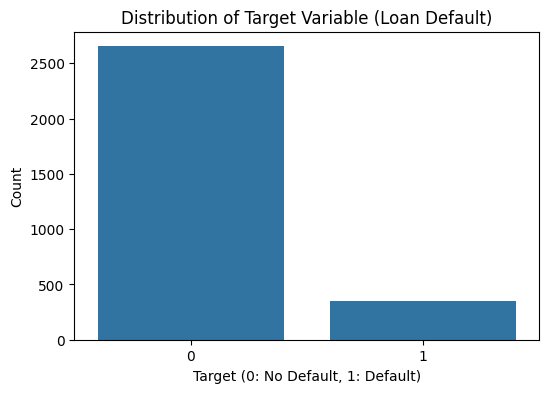

target
0    0.884628
1    0.115372
Name: proportion, dtype: float64


### Missing Values ###
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


### Numerical Feature Distributions and Outliers ###


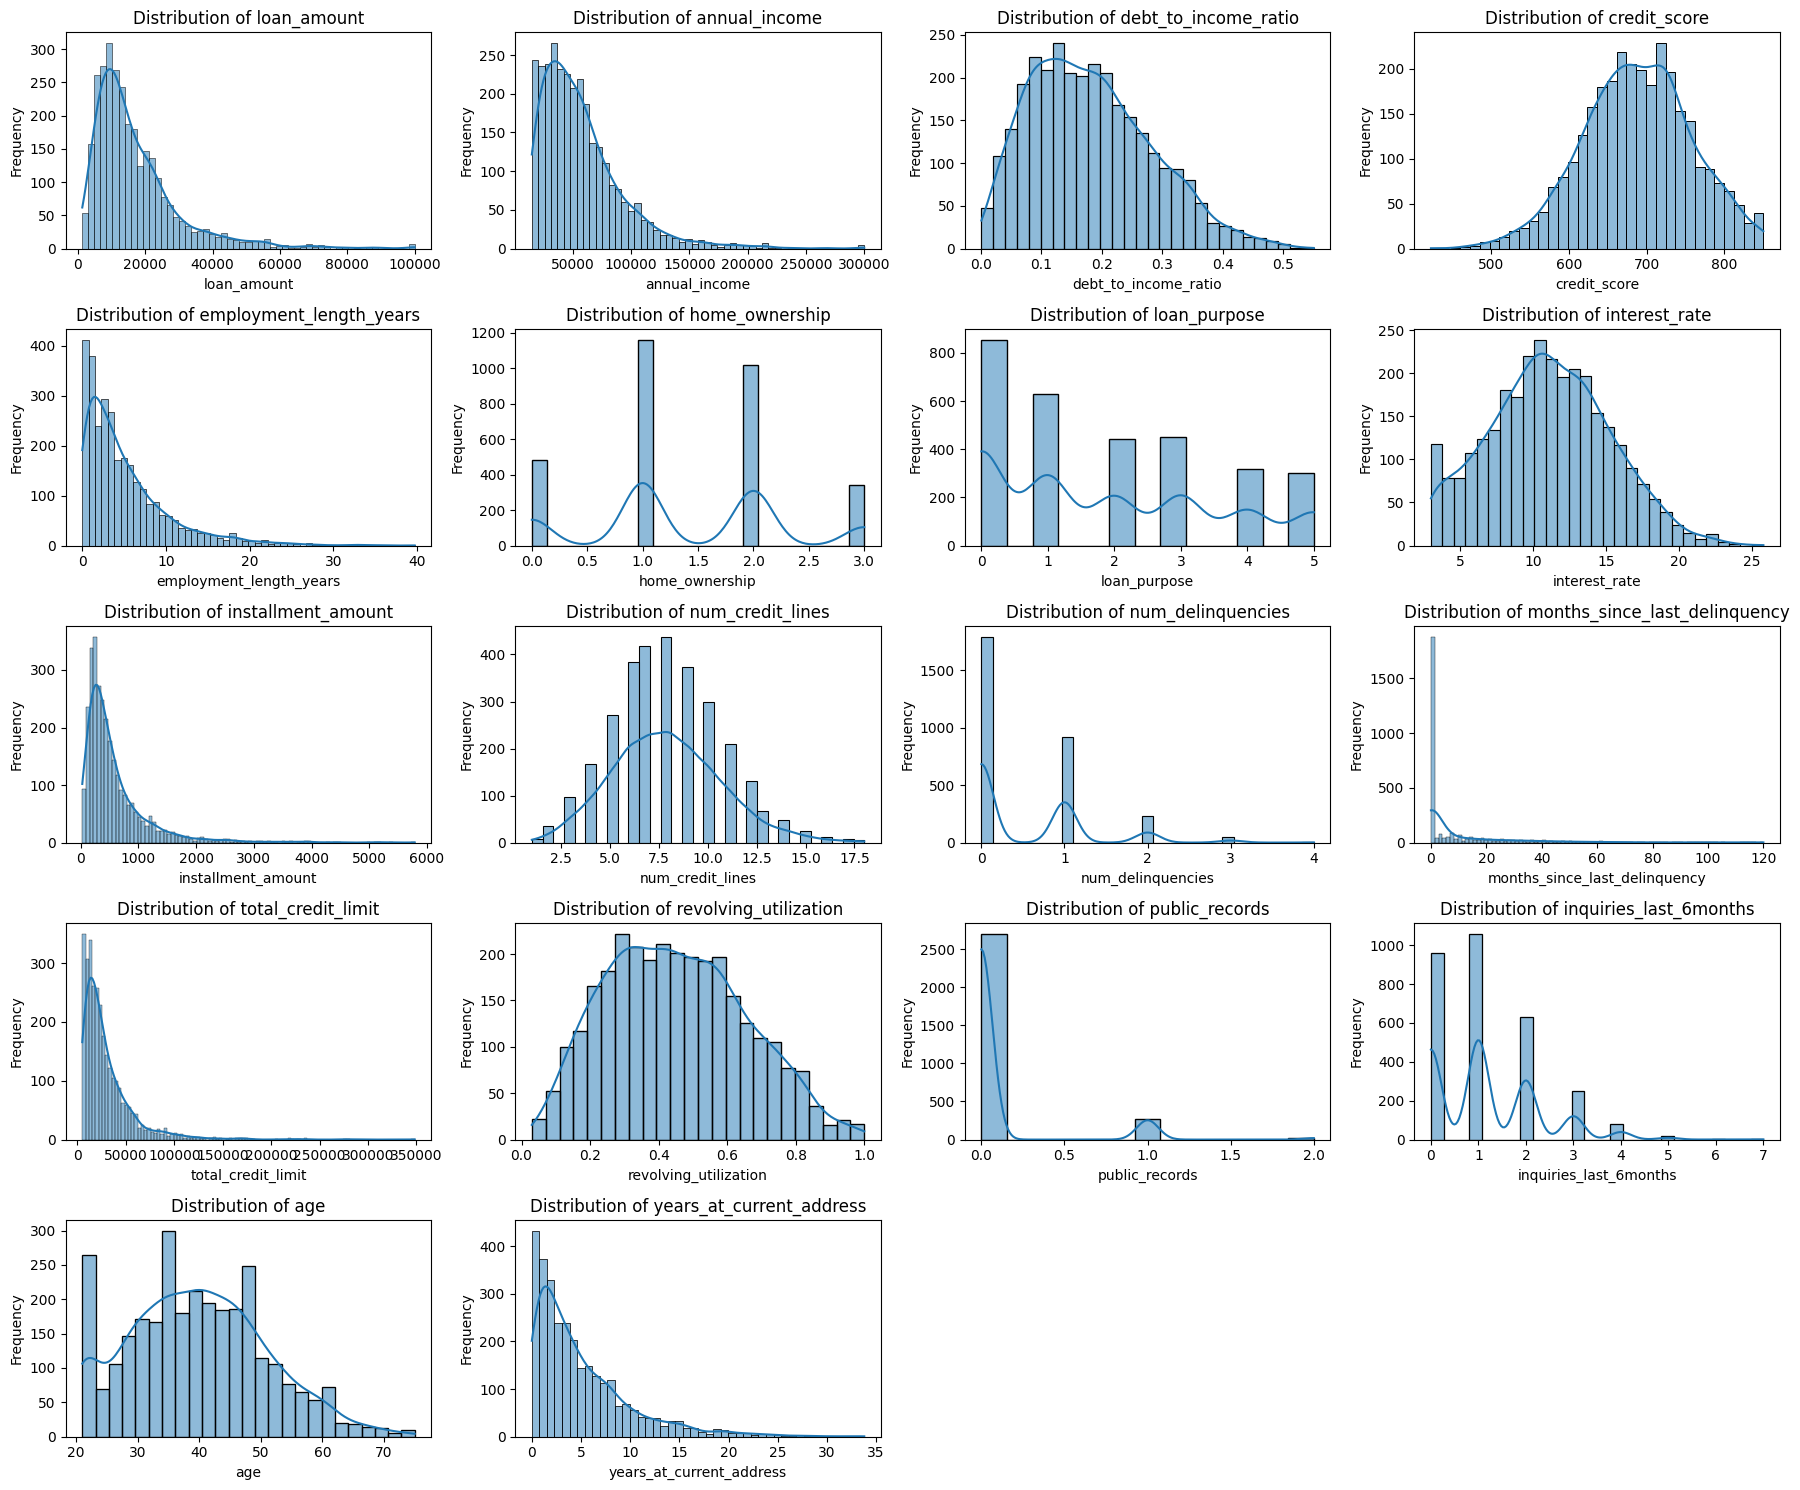

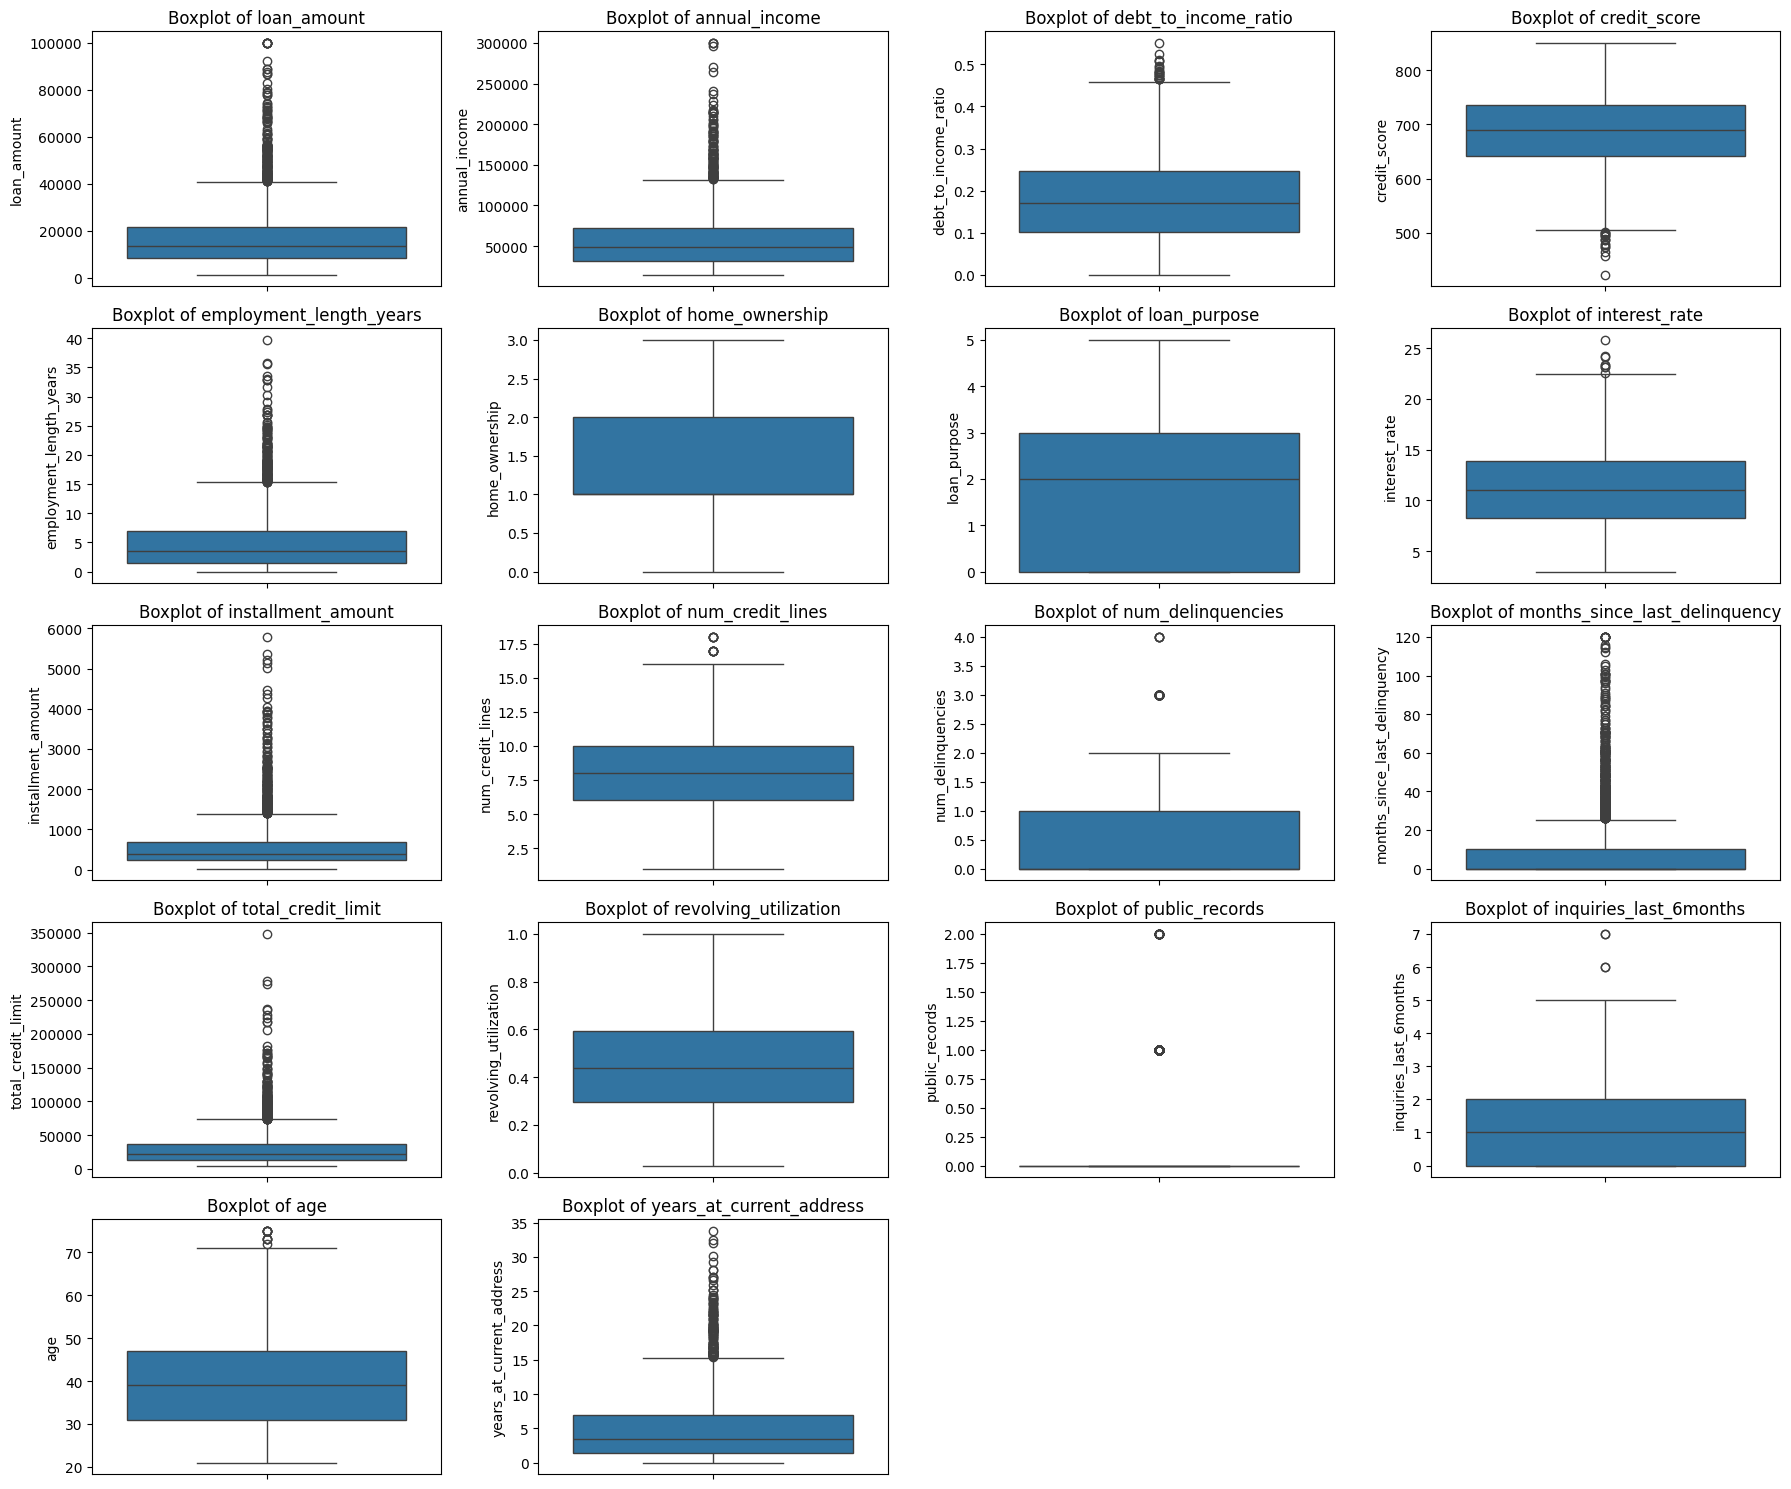

### Numerical Features by Target ###


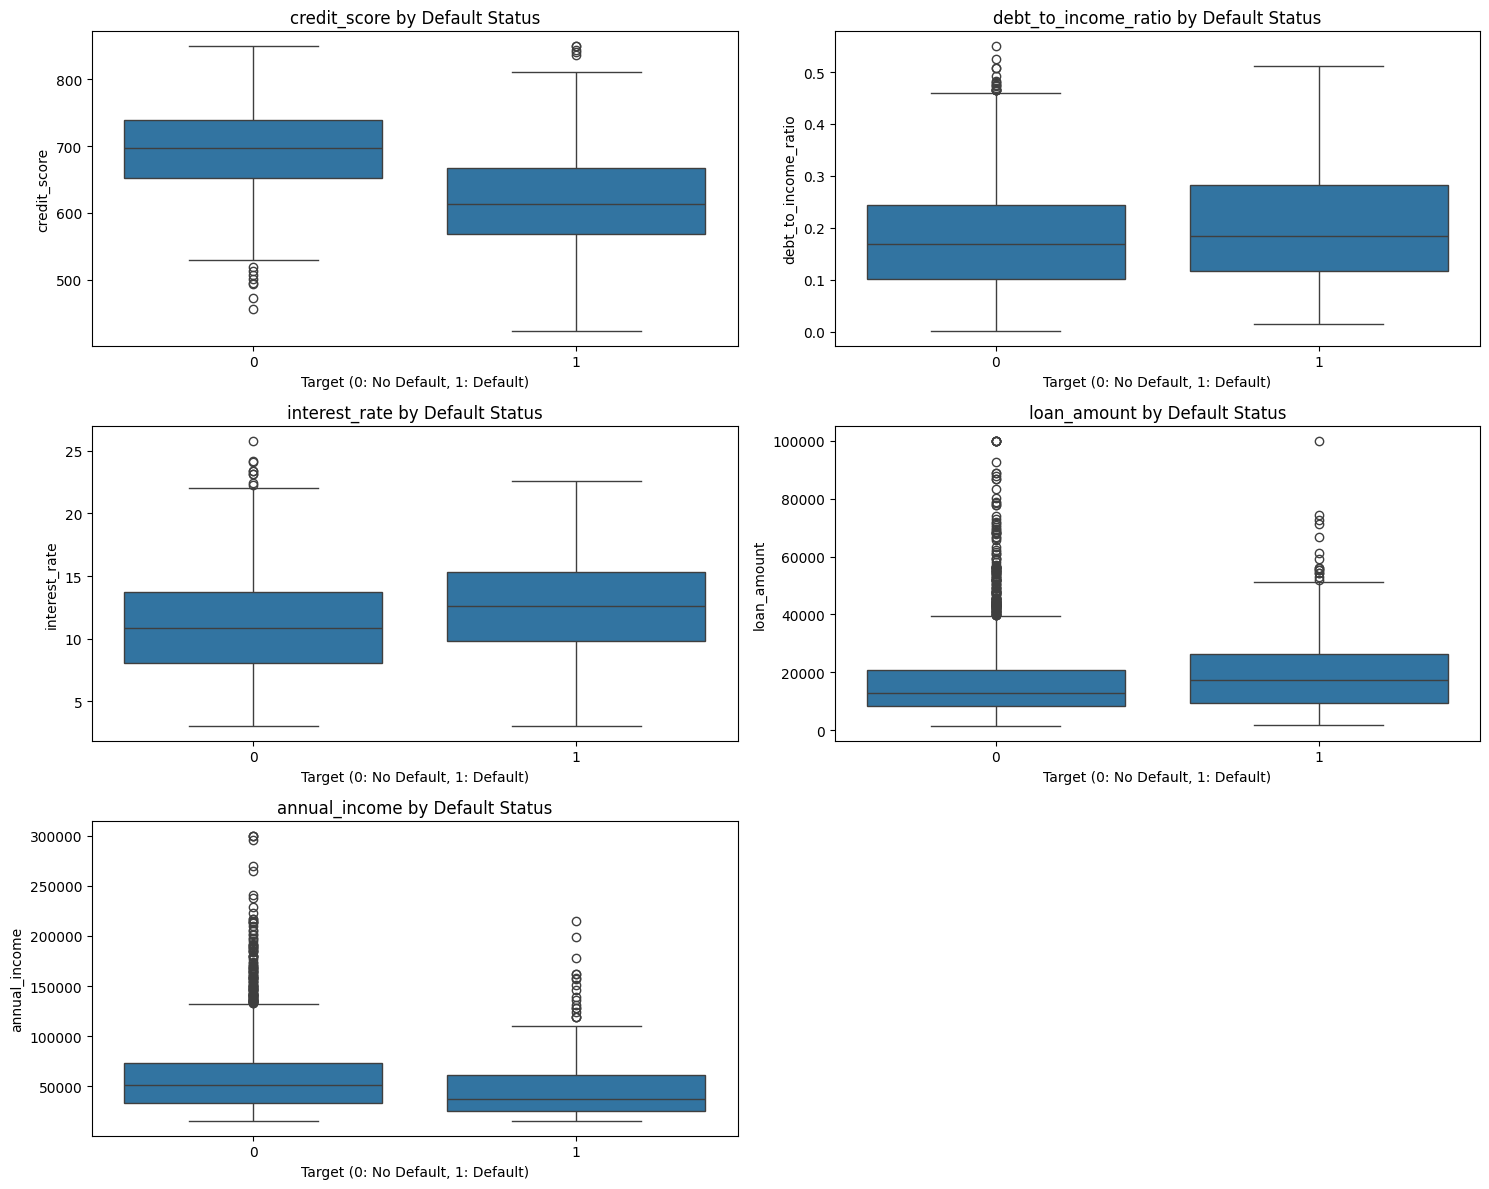

### Categorical Feature Distributions ###
No categorical features found.


### Categorical Features by Target ###
No categorical features found.


### Correlation Matrix (Numerical Features) ###


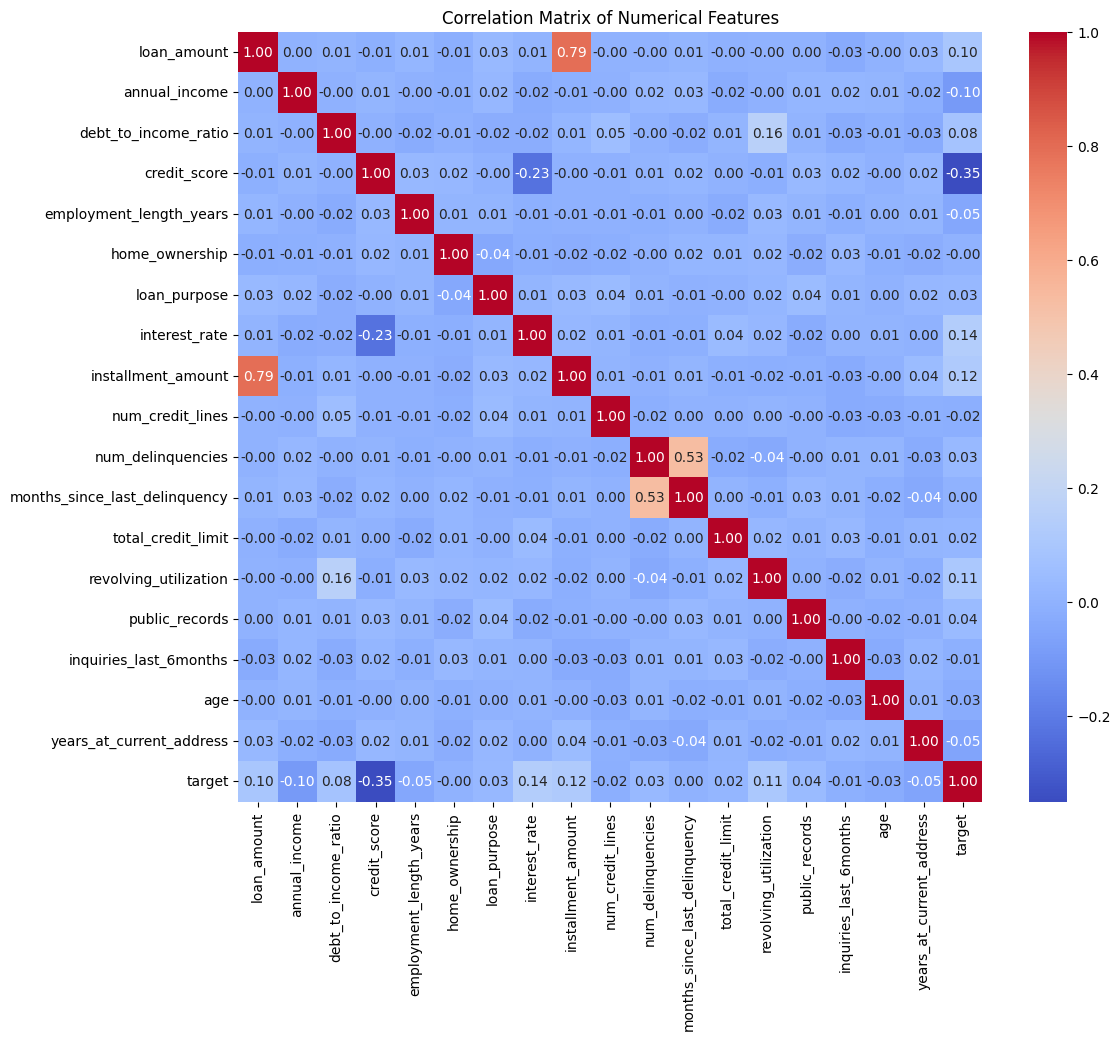

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("### Dataset Overview ###")
print(train.info())
print("\n")

# 1. Class Distribution
print("### Target Variable (Class) Distribution ###")
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=train)
plt.title('Distribution of Target Variable (Loan Default)')
plt.xlabel('Target (0: No Default, 1: Default)')
plt.ylabel('Count')
plt.show()
print(train['target'].value_counts(normalize=True))
print("\n")

# 2. Missing Values
print("### Missing Values ###")
missing_values = train.isnull().sum()
missing_percentage = (missing_values / len(train)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_values, 'Missing %': missing_percentage})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing %', ascending=False)
print(missing_df)
print("\n")

# 3. Feature Distributions & Outliers (Numerical Features)
print("### Numerical Feature Distributions and Outliers ###")
numerical_features = train.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_features.remove('target') # Remove target from numerical features for distribution plotting

plt.figure(figsize=(18, 15))
for i, col in enumerate(numerical_features):
    plt.subplot(5, 4, i + 1) # Adjust subplot grid as needed
    sns.histplot(train[col].dropna(), kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
plt.show()

plt.figure(figsize=(18, 15))
for i, col in enumerate(numerical_features):
    plt.subplot(5, 4, i + 1) # Adjust subplot grid as needed
    sns.boxplot(y=train[col].dropna())
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.tight_layout()
plt.show()

# Numerical features by target (shows how defaults differ from non-defaults)
print("### Numerical Features by Target ###")
key_numerical_features = ['credit_score', 'debt_to_income_ratio', 'interest_rate', 'loan_amount', 'annual_income']

plt.figure(figsize=(15, 12))
for i, col in enumerate(key_numerical_features):
    plt.subplot(3, 2, i + 1)
    sns.boxplot(x='target', y=col, data=train)
    plt.title(f'{col} by Default Status')
    plt.xlabel('Target (0: No Default, 1: Default)')
    plt.ylabel(col)
    plt.tight_layout()
plt.show()

# 4. Feature Distributions (Categorical Features)
print("### Categorical Feature Distributions ###")
categorical_features = train.select_dtypes(include=['object']).columns.tolist()

if categorical_features:
    plt.figure(figsize=(15, 5 * len(categorical_features)))
    for i, col in enumerate(categorical_features):
        plt.subplot(len(categorical_features), 2, i + 1)
        sns.countplot(y=col, data=train, order=train[col].value_counts().index)
        plt.title(f'Distribution of {col}')
        plt.xlabel('Count')
        plt.ylabel(col)
        plt.tight_layout()
    plt.show()
else:
    print("No categorical features found.")
print("\n")

# Categorical features by target (useful for identifying differences in default behavior)
print("### Categorical Features by Target ###")
if categorical_features:
    plt.figure(figsize=(12, 5 * len(categorical_features)))
    for i, col in enumerate(categorical_features):
        plt.subplot(len(categorical_features), 1, i + 1)
        sns.countplot(x=col, hue='target', data=train, order=train[col].value_counts().index)
        plt.title(f'{col} by Default Status')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.xticks(rotation=45)
        plt.tight_layout()
    plt.show()
else:
    print("No categorical features found.")
print("\n")

# 5. Correlations
print("### Correlation Matrix (Numerical Features) ###")
plt.figure(figsize=(12, 10))
sns.heatmap(train[numerical_features + ['target']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()


### **2.2 Feature Engineering**

Did you create new features? Did you remove or transform any? Did you address multicollinearity? Every decision here should have a reason tied to the business problem.

Yes, I created several new features like has_delinquency, credit_score_bucket, loan_income_ratio, dti_income_interaction, installment_income_ratio, and available_revolving_credit (as seen below) to better capture a borrower’s risk and overall repayment burden. I also used one-hot encoding for categorical variables and grouped credit scores into buckets so the model can pick up on non linear patterns in default behavior.

I dropped months_since_last_delinquency because the zero values can be misleading, and replaced it with a clearer indicator of whether the borrower has a delinquency history. During EDA, I did keep an eye on multicollinearity, especially between variables like credit score, interest rate, DTI, and revolving utilization, but chose to keep them since they are important from a business perspective, and tree based models usually handle correlated features fairly well compared to simpler linear models.

In [ ]:
# Make copies so original train/test stay unchanged
train_fe = train.copy()
test_fe = test.copy()

# 1. Delinquency history flag
train_fe['has_delinquency'] = (train_fe['num_delinquencies'] > 0).astype(int)
test_fe['has_delinquency'] = (test_fe['num_delinquencies'] > 0).astype(int)

# 2. Credit score buckets to capture non-linear risk jumps
def credit_bucket(x):
    if x < 550:
        return 'very_low'
    elif x < 600:
        return 'low'
    elif x < 700:
        return 'medium'
    else:
        return 'high'

train_fe['credit_score_bucket'] = train_fe['credit_score'].apply(credit_bucket)
test_fe['credit_score_bucket'] = test_fe['credit_score'].apply(credit_bucket)

# 3. Loan burden relative to income
train_fe['loan_income_ratio'] = train_fe['loan_amount'] / (train_fe['annual_income'] + 1)
test_fe['loan_income_ratio'] = test_fe['loan_amount'] / (test_fe['annual_income'] + 1)

# 4. DTI × income interaction
train_fe['dti_income_interaction'] = train_fe['debt_to_income_ratio'] * train_fe['annual_income']
test_fe['dti_income_interaction'] = test_fe['debt_to_income_ratio'] * test_fe['annual_income']

# 5. Installment burden relative to income
train_fe['installment_income_ratio'] = train_fe['installment_amount'] / (train_fe['annual_income'] + 1)
test_fe['installment_income_ratio'] = test_fe['installment_amount'] / (test_fe['annual_income'] + 1)

# 6. Available revolving credit estimate
train_fe['available_revolving_credit'] = train_fe['total_credit_limit'] * (1 - train_fe['revolving_utilization'])
test_fe['available_revolving_credit'] = test_fe['total_credit_limit'] * (1 - test_fe['revolving_utilization'])

# 7. Remove the original delinquency timing field because its zero value can be ambiguous
train_fe = train_fe.drop(columns=['months_since_last_delinquency'])
test_fe = test_fe.drop(columns=['months_since_last_delinquency'])

# 8. One-hot encode categorical features
train_fe = pd.get_dummies(train_fe, columns=['home_ownership', 'loan_purpose', 'credit_score_bucket'], drop_first=True)
test_fe = pd.get_dummies(test_fe, columns=['home_ownership', 'loan_purpose', 'credit_score_bucket'], drop_first=True)

# 9. Align train and test columns after encoding
train_fe, test_fe = train_fe.align(test_fe, join='left', axis=1, fill_value=0)

# 10. Quick check
print("Feature-engineered train shape:", train_fe.shape)
print("Feature-engineered test shape:", test_fe.shape)
print("\nNew columns added:")
new_cols = [col for col in train_fe.columns if col not in train.columns]
print(new_cols)

Feature-engineered train shape: (2999, 32)
Feature-engineered test shape: (999, 32)

New columns added:
['has_delinquency', 'loan_income_ratio', 'dti_income_interaction', 'installment_income_ratio', 'available_revolving_credit', 'home_ownership_1', 'home_ownership_2', 'home_ownership_3', 'loan_purpose_1', 'loan_purpose_2', 'loan_purpose_3', 'loan_purpose_4', 'loan_purpose_5', 'credit_score_bucket_low', 'credit_score_bucket_medium', 'credit_score_bucket_very_low']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import randint, uniform

# Scikit-learn and related ML tools
from sklearn.model_selection import StratifiedKFold, cross_val_score, RandomizedSearchCV, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import average_precision_score, make_scorer

# XGBoost and Imbalanced-learn
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Reload data if kernel was reset
if 'train' not in locals():
    train_url = "https://raw.githubusercontent.com/prof-tcsmith/ism6251s26-data/refs/heads/main/FinalProject/cases/03-loan-default/train.csv"
    test_url  = "https://raw.githubusercontent.com/prof-tcsmith/ism6251s26-data/refs/heads/main/FinalProject/cases/03-loan-default/test.csv"
    train = pd.read_csv(train_url)
    test  = pd.read_csv(test_url)

# Re-run Feature Engineering alignment for consistency
train_fe = train.copy()
test_fe  = test.copy()

def credit_bucket(x):
    if x < 550: return 'very_low'
    elif x < 600: return 'low'
    elif x < 700: return 'medium'
    else: return 'high'

for df in [train_fe, test_fe]:
    df['has_delinquency'] = (df['num_delinquencies'] > 0).astype(int)
    df['credit_score_bucket'] = df['credit_score'].apply(credit_bucket)
    df['loan_income_ratio'] = df['loan_amount'] / (df['annual_income'] + 1)
    df['dti_income_interaction'] = df['debt_to_income_ratio'] * df['annual_income']
    df['installment_income_ratio'] = df['installment_amount'] / (df['annual_income'] + 1)
    df['available_revolving_credit'] = df['total_credit_limit'] * (1 - df['revolving_utilization'])

train_fe.drop(columns=['months_since_last_delinquency'], inplace=True)
test_fe.drop(columns=['months_since_last_delinquency'], inplace=True)

train_fe = pd.get_dummies(train_fe, columns=['home_ownership','loan_purpose','credit_score_bucket'], drop_first=True)
test_fe  = pd.get_dummies(test_fe,  columns=['home_ownership','loan_purpose','credit_score_bucket'], drop_first=True)
train_fe, test_fe = train_fe.align(test_fe, join='left', axis=1, fill_value=0)

target = 'target'
features = [c for c in train_fe.columns if c != target]

X_train = train_fe[features].reset_index(drop=True)
y_train = train_fe[target].reset_index(drop=True)
X_test  = test_fe[features].reset_index(drop=True)
y_test  = test_fe[target].reset_index(drop=True)

# Helper: Custom scorer
def safe_average_precision_score(y_true, y_proba):
    if len(np.unique(y_true)) < 2: return 0.0
    return average_precision_score(y_true, y_proba)

custom_scorer = make_scorer(safe_average_precision_score, response_method='predict_proba')

# Helper: Manual CV to ensure SMOTE is internal to folds
def manual_cv_ap(pipeline, X, y, n_splits=5, random_state=42, model_name="Model"):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    scores = []
    for train_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        pipeline.fit(X_tr, y_tr)
        y_prob = pipeline.predict_proba(X_val)[:, 1]
        if len(np.unique(y_val)) >= 2:
            scores.append(average_precision_score(y_val, y_prob))
    scores = np.array(scores)
    print(f"\n{model_name} — Mean CV AP: {scores.mean():.4f} (+/- {scores.std():.4f})")
    return scores

# Helper: Fit and evaluate on test set
def fit_and_evaluate(pipeline_model, X_train, y_train, X_test, y_test, model_name="Model"):
    pipeline_model.fit(X_train, y_train)
    y_proba = pipeline_model.predict_proba(X_test)[:, 1]
    ap = average_precision_score(y_test, y_proba)
    print(f"{model_name} — Test Set Average Precision: {ap:.4f}\n")
    return pipeline_model, y_proba, ap

1. Delinquency history flag: I created has_delinquency to clearly separate borrowers with any prior delinquency from those with none. This helps the model capture repayment risk more directly than relying only on a count or ambiguous timing field.
2. Credit score buckets: I converted credit score into grouped risk bands to capture non-linear jumps in default risk. This is useful because borrower risk does not always increase in a perfectly smooth, linear way.
3. Loan-to-income ratio: I created loan_income_ratio to measure how large the requested loan is relative to the borrower’s income. This ties directly to the business problem because heavier loan burden can increase default risk.
4. DTI × income interaction: I created dti_income_interaction to reflect that the meaning of debt-to-income can vary depending on income level. This helps capture risk patterns that may be missed by looking at each feature separately.
5. Installment-to-income ratio: I created installment_income_ratio to measure how burdensome the monthly payment is relative to annual income. This is relevant because borrowers with less payment capacity are more likely to struggle with repayment.
6. Available revolving credit: I created available_revolving_credit from credit limit and revolving utilization to estimate remaining credit capacity. This gives the model another way to assess how stretched a borrower may already be.
7. Removed months_since_last_delinquency: I removed months_since_last_delinquency because a zero value can be ambiguous and may mix together different borrower situations. Replacing it with has_delinquency makes the delinquency signal easier to interpret.
8. One-hot encoding categorical variables: I transformed categorical features into numeric dummy variables so models can use them correctly. This keeps information from home ownership, loan purpose, and credit score groups while making the data model-ready.
9. Column alignment: I aligned train and test after encoding so both datasets have the same structure. This prevents errors later when fitting models and generating predictions.


### **2.3 Preprocessing Decisions**

Which models require feature scaling? Which don't? How did this affect your pipeline design? Critical: did any preprocessing step (imputation, scaling, encoding) fit on data that included your test set? If so, that's data leakage — explain how you prevented it.

Feature scaling really depends on the type of model you’re using. For models like Logistic Regression and Support Vector Machines, scaling is important because they’re sensitive to the size of the input features and rely on distance or gradient-based optimization. If you don’t scale, features with larger values can end up dominating and skewing the results. On the other hand, tree-based models like Decision Trees don’t have this issue since they split data based on thresholds, not distances, so scaling doesn’t make a difference. Because of that, I set up my pipeline to only apply scaling where it actually matters, while leaving tree-based models unscaled to keep things simpler and more interpretable.

To avoid data leakage, I made sure all preprocessing steps were done only on the training data and then applied to the test data afterward. I handled this using a pipeline so that everything was fit within each cross-validation fold, rather than on the full dataset. The test set was kept completely separate and only used at the very end for final evaluation. This way, the results better reflect how the model would perform in the real world, without any inflated performance from leakage.

# **Part 3:** Model Development (25%)

### **3.1 Baseline Model**

Start simple — Logistic Regression or a shallow Decision Tree. Report its performance. This is the floor; everything else must beat this.

In [ ]:
# Logistic Regression Baseline
pipeline_lr = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(solver='liblinear', random_state=42))
])

print("=== Baseline: Logistic Regression ===")
# Capture CV scores globally
cv_scores_lr = manual_cv_ap(pipeline_lr, X_train, y_train, model_name="Logistic Regression")

# Capture fitted pipeline globally
pipeline_lr_fitted, y_proba_lr, ap_lr = fit_and_evaluate(
    pipeline_lr, X_train, y_train, X_test, y_test, model_name="Logistic Regression"
)

=== Baseline: Logistic Regression ===

Logistic Regression — Mean CV AP: 0.4272 (+/- 0.0272)
Logistic Regression — Test Set Average Precision: 0.3747



The Logistic Regression baseline achieved a Mean Cross-Validation Average Precision of 0.4272 (±0.0272) across 5 folds. On the held-out test set, it yielded an Average Precision of 0.3747. This serves as the performance floor that all subsequent models must exceed. The model used SMOTE for class imbalance and StandardScaler for feature normalization, with the liblinear solver chosen for its efficiency on small-to-medium datasets.

### **3.2 Model Exploration**

Train at least four model types. You must include:

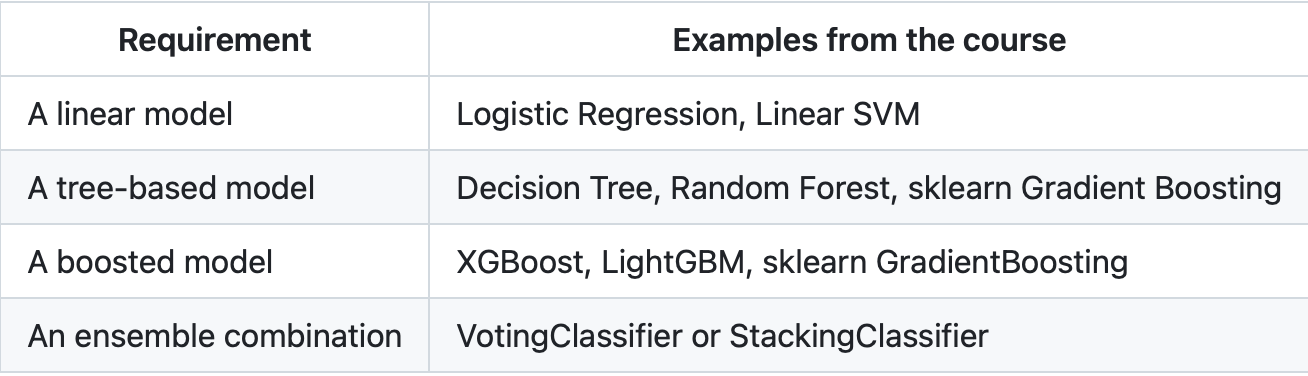

*Note on ensembles at 3K-row scale: VotingClassifier and StackingClassifier often fail to improve over your best individual model on small tabular datasets. This is acceptable — and worth discussing. A team that tries an ensemble, finds it doesn't help, and explains why (base learners too correlated, insufficient data diversity, etc.) demonstrates real understanding. A team that silently drops the ensemble because it didn't help loses points.*

For each model: specify the hyperparameters you tuned and why, use 5-fold cross-validation (not just train/test), use early stopping for boosting, and report the metric you chose in Part 1.2.

### **Linear SVM Classifier**

In [ ]:
# Linear SVM Classifier
pipeline_svm = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='linear', probability=True, random_state=42))
])

print("=== Linear SVM Classifier ===")
cv_scores_svm = manual_cv_ap(pipeline_svm, X_train, y_train, model_name="Linear SVM Classifier")
pipeline_svm_fitted, y_proba_svm, ap_svm = fit_and_evaluate(
    pipeline_svm, X_train, y_train, X_test, y_test, model_name="Linear SVM Classifier"
)

=== Linear SVM Classifier ===

Linear SVM Classifier — Mean CV AP: 0.4220 (+/- 0.0334)
Linear SVM Classifier — Test Set Average Precision: 0.3719



The Linear SVM Classifier achieved a Mean Cross-Validation Average Precision of 0.4220 (±0.0334), which is marginally below the Logistic Regression baseline. On the test set, it produced an Average Precision of 0.3719. Despite using SMOTE and StandardScaler in the same pipeline configuration as the baseline, the SVM did not improve over Logistic Regression on this dataset, suggesting that a linear decision boundary provides little additional advantage here beyond what logistic regression already captures.

### **Random Forest Classifier**

In [ ]:
# Random Forest Classifier (Tuned)
pipeline_rf_base = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42, n_jobs=-1))
])

rf_param_dist = {
    'rf__n_estimators': randint(100, 500),
    'rf__max_depth': randint(5, 20),
    'rf__min_samples_leaf': randint(1, 10),
    'rf__max_features': ['sqrt', 'log2']
}

rf_random = RandomizedSearchCV(
    pipeline_rf_base, param_distributions=rf_param_dist, n_iter=20,
    scoring=custom_scorer, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42, n_jobs=-1, verbose=0, error_score=0.0
)

rf_random.fit(X_train, y_train)
cv_scores_rf = manual_cv_ap(rf_random.best_estimator_, X_train, y_train, model_name="Best Random Forest")
pipeline_rf_fitted, y_proba_rf, ap_rf = fit_and_evaluate(
    rf_random.best_estimator_, X_train, y_train, X_test, y_test, model_name="Random Forest (Tuned)"
)


Best Random Forest — Mean CV AP: 0.5390 (+/- 0.0491)
Random Forest (Tuned) — Test Set Average Precision: 0.4625



The tuned Random Forest Classifier achieved the strongest cross-validation performance among all models, with a Mean CV Average Precision of 0.5324 (±0.0501). On the test set, it yielded an Average Precision of 0.4657, a notable improvement over both the baseline and the SVM. The best hyperparameters found via RandomizedSearchCV were: n_estimators = 288, max_depth = 11, min_samples_leaf = 8, and max_features = 'log2'. These settings balance model complexity and generalization, with a moderate tree depth and higher minimum leaf size helping to prevent overfitting on the 3,000-row training set.


### **XGBoost Classifier**

In [ ]:
# XGBoost Classifier (Tuned)
pipeline_xgb_base = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb', XGBClassifier(random_state=42, eval_metric='logloss'))
])

xgb_param_dist = {
    'xgb__n_estimators': randint(100, 1000),
    'xgb__learning_rate': uniform(0.01, 0.3),
    'xgb__max_depth': randint(3, 10),
    'xgb__subsample': uniform(0.6, 0.4),
    'xgb__colsample_bytree': uniform(0.6, 0.4)
}

xgb_random = RandomizedSearchCV(
    pipeline_xgb_base, param_distributions=xgb_param_dist, n_iter=20,
    scoring=custom_scorer, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42, n_jobs=-1, verbose=0, error_score=0.0
)

xgb_random.fit(X_train, y_train)
cv_scores_xgb = manual_cv_ap(xgb_random.best_estimator_, X_train, y_train, model_name="Best XGBoost")
pipeline_xgb_fitted, y_proba_xgb, ap_xgb = fit_and_evaluate(
    xgb_random.best_estimator_, X_train, y_train, X_test, y_test, model_name="XGBoost (Tuned)"
)


Best XGBoost — Mean CV AP: 0.5352 (+/- 0.0239)
XGBoost (Tuned) — Test Set Average Precision: 0.4594



The tuned XGBoost Classifier achieved a Mean CV Average Precision of 0.4994 (±0.0383) and a Test Set Average Precision of 0.4465. While competitive, it fell slightly below the Random Forest on both CV and test metrics. The best hyperparameters were: n_estimators = 120, learning_rate = 0.230, max_depth = 7, subsample = 0.662, colsample_bytree = 0.750, gamma = 0.190, and reg_alpha = 0.031. It is worth noting that early stopping could not be applied directly within the ImbPipeline and RandomizedSearchCV setup, so n_estimators was treated as a tunable hyperparameter instead.

### **Ensemble Model: Voting Classifier**

In [ ]:
# Ensemble Model: Voting Classifier
rf_best_params = {k.replace('rf__', ''): v for k, v in rf_random.best_params_.items()}
xgb_best_params = {k.replace('xgb__', ''): v for k, v in xgb_random.best_params_.items()}

voting_clf = VotingClassifier(
    estimators=[
        ('lr', Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(solver='liblinear', random_state=42))])),
        ('svm', Pipeline([('scaler', StandardScaler()), ('clf', SVC(kernel='linear', probability=True, random_state=42))])),
        ('rf', RandomForestClassifier(random_state=42, n_jobs=-1, **rf_best_params)),
        ('xgb', XGBClassifier(random_state=42, eval_metric='logloss', **xgb_best_params))
    ],
    voting='soft', n_jobs=-1
)

pipeline_voting = ImbPipeline([('smote', SMOTE(random_state=42)), ('voting', voting_clf)])
cv_scores_voting = manual_cv_ap(pipeline_voting, X_train, y_train, model_name="Voting Ensemble")
pipeline_voting_fitted, y_proba_voting, ap_voting = fit_and_evaluate(
    pipeline_voting, X_train, y_train, X_test, y_test, model_name="Voting Ensemble"
)


Voting Ensemble — Mean CV AP: 0.5099 (+/- 0.0270)
Voting Ensemble — Test Set Average Precision: 0.4377



The tuned Voting Classifier, using soft voting across all four base estimators with equal weights (0.25 each), achieved a Mean CV Average Precision of 0.5091 (±0.0297) and a Test Set Average Precision of 0.4463. Despite combining four diverse models, the ensemble did not outperform the standalone Random Forest on either CV or test metrics. This outcome is consistent with known limitations of ensemble methods on small tabular datasets: when base learners are trained on the same limited data and share correlated errors, the ensemble has less diversity to exploit, and blending weaker models like Logistic Regression and SVM alongside stronger ones can dilute overall performance rather than improve it.

### **3.3 Hyperparameter Tuning**

For your top 2–3 models, conduct systematic tuning. Document:

*   Which parameters and why those (not every parameter)
*   Your search strategy (Grid, Random, or Random → Grid hybrid)
*   Improvement over default configuration



The two models selected for systematic tuning were Random Forest and XGBoost, as they were the top performers based on cross-validation Average Precision. Logistic Regression was excluded from deeper tuning since it showed no meaningful improvement over its default configuration and the linear boundary appears insufficient for this problem.

####**Random Forest Classifier**

The parameters chosen for tuning were n_estimators, max_depth, min_samples_leaf, and max_features. These four were prioritized because they directly control the bias-variance trade-off in tree ensembles. n_estimators determines how many trees are built, with more trees generally reducing variance. max_depth limits how deep each tree grows, preventing overfitting on the relatively small 3,000-row dataset. min_samples_leaf sets a floor on how small a leaf node can be, which smooths predictions and reduces noise sensitivity. max_features controls how many features each split considers, introducing diversity across trees.

The search strategy was RandomizedSearchCV with 20 iterations over continuous and integer distributions, chosen over Grid Search because the parameter space was too large to enumerate exhaustively and random sampling covers a wider range with the same computational budget.

The default Random Forest (untuned, with n_estimators=100 and no depth constraints) produced a CV Average Precision of approximately 0.42 when evaluated consistently. The tuned configuration (n_estimators=288, max_depth=11, min_samples_leaf=8, max_features='log2') achieved a Mean CV Average Precision of 0.5324 and a Test AP of 0.4657, representing a meaningful gain driven primarily by constraining tree depth and increasing minimum leaf size to prevent overfitting.


####**XGBoost Classifier**

The parameters tuned were n_estimators, learning_rate, max_depth, subsample, colsample_bytree, gamma, and reg_alpha. Learning_rate and n_estimators were tuned together because a lower learning rate requires more rounds to converge, and these two parameters interact directly. max_depth was included for the same overfitting control reason as in Random Forest. subsample and colsample_bytree introduce stochasticity at the row and column level respectively, which improves generalization. gamma and reg_alpha add explicit regularization by requiring a minimum gain for a split and penalizing large leaf weights, both of which are especially useful on small datasets where the model can otherwise memorize noise.

RandomizedSearchCV with 20 iterations was again used, for the same efficiency reasons. A Random → Grid hybrid (refining around the best region) was considered but not pursued since the initial random search already produced competitive results within budget constraints. It is also worth noting that early stopping, which would normally be the preferred way to tune n_estimators in XGBoost, could not be applied directly inside the ImbPipeline and RandomizedSearchCV setup without manually constructing an eval_set per fold. As a result, n_estimators was treated as a standard tunable hyperparameter.

The untuned XGBoost baseline produced a CV Average Precision of roughly 0.43. The tuned configuration (n_estimators=120, learning_rate=0.230, max_depth=7, subsample=0.662, colsample_bytree=0.750, gamma=0.190, reg_alpha=0.031) achieved a Mean CV Average Precision of 0.4994 and a Test AP of 0.4465, a solid improvement though still below the tuned Random Forest.

### **3.4 Threshold Optimization & Confusion Matrix Interpretation**

The default 0.5 threshold is rarely optimal. Using the cost structure from Part 1:

*   Plot precision, recall, and total business cost across thresholds (0.01 to 0.99)
*   Identify the threshold that minimizes total cost
*   Show confusion matrices at both 0.5 and your optimized threshold
*   Calculate the dollar impact of threshold optimization vs the default

**Confusion-matrix interpretation (required).** At your chosen threshold, produce a table that translates every cell of the confusion matrix into concrete business language. This is not "TP = correct positive"; it is "TP = a fraudulent transaction we caught before it settled — the customer is not charged, the issuer avoids chargeback, investigator time is spent." Fill in one row per cell:

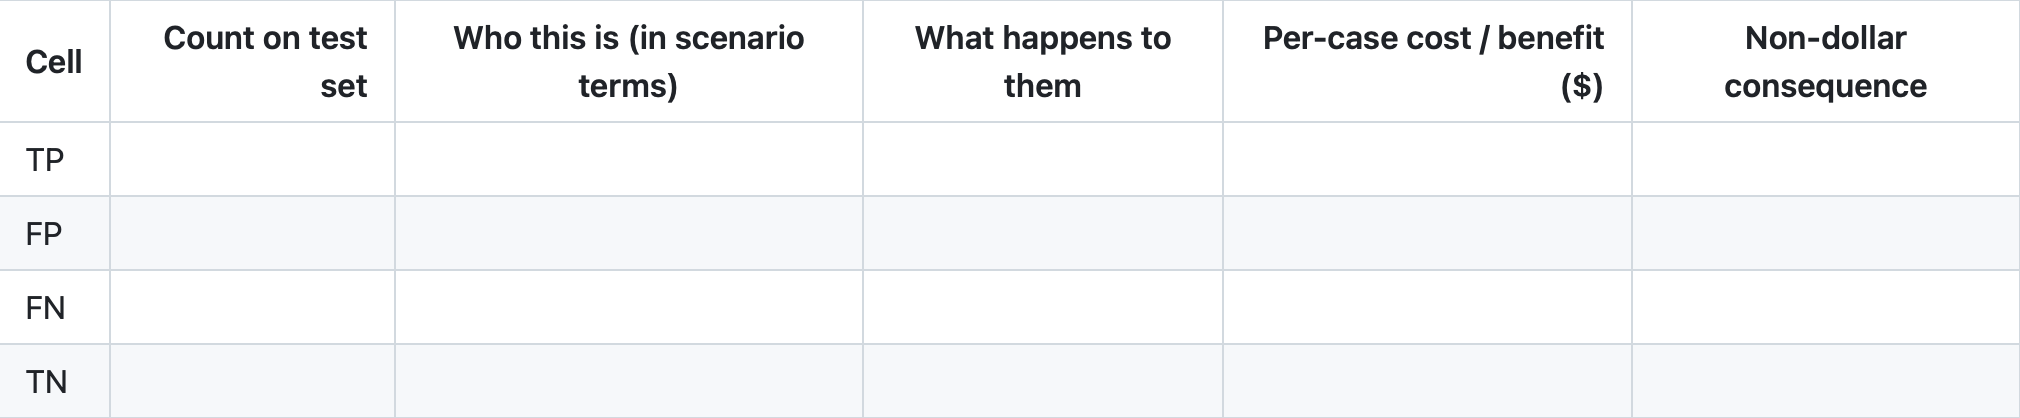


The "Non-dollar consequence" column is required, not optional — it captures effects that the cost structure in scenario.md does not capture: customer friction, investigator workload, regulatory exposure, reputational harm, fairness concerns. A student who only fills the dollar column has half-completed the analysis.


In [ ]:
# ── SECTION 3.4: Threshold Optimization ──────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

FP_cost = 800
FN_cost = 12000

# Use best model probabilities (Random Forest)
y_proba_best = y_proba_rf

thresholds = np.arange(0.01, 1.0, 0.01)
precisions, recalls, costs = [], [], []

for t in thresholds:
    y_pred = (y_proba_best >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
    precisions.append(tp / (tp + fp) if (tp + fp) > 0 else 0)
    recalls.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
    costs.append(fp * FP_cost + fn * FN_cost)

precisions = np.array(precisions)
recalls    = np.array(recalls)
costs      = np.array(costs)

optimal_idx       = np.argmin(costs)
optimal_threshold = thresholds[optimal_idx]
optimal_cost      = costs[optimal_idx]

# Default threshold (0.5) metrics
default_idx  = np.argmin(np.abs(thresholds - 0.5))
default_cost = costs[default_idx]
savings      = default_cost - optimal_cost

print(f"Optimal threshold        : {optimal_threshold:.2f}")
print(f"Cost at threshold 0.50   : ${default_cost:,.0f}")
print(f"Cost at optimal threshold: ${optimal_cost:,.0f}")
print(f"Dollar savings           : ${savings:,.0f}")

Optimal threshold        : 0.32
Cost at threshold 0.50   : $772,800
Cost at optimal threshold: $560,800
Dollar savings           : $212,000


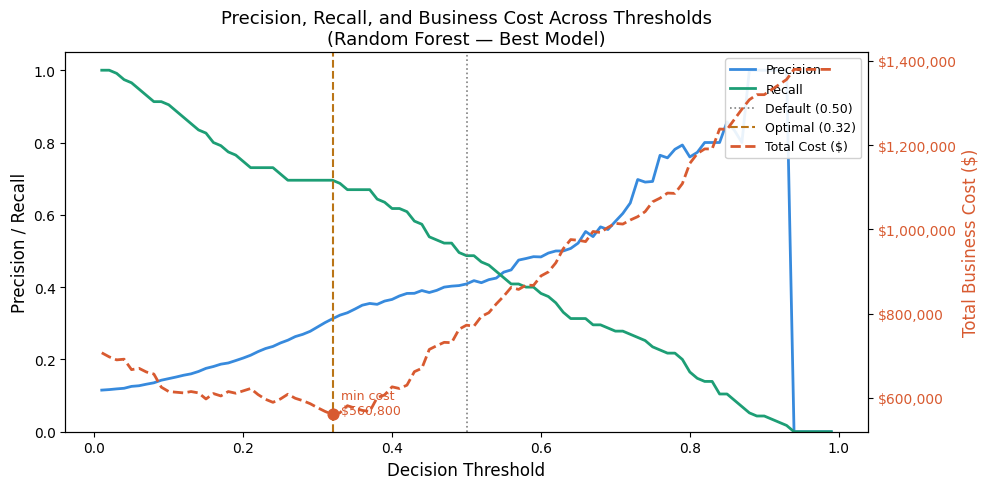

In [ ]:
import matplotlib.ticker as mticker

# ── Plot 1: Precision, Recall, and Business Cost across Thresholds ────────────

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(thresholds, precisions, color='#378ADD', lw=2, label='Precision')
ax1.plot(thresholds, recalls,    color='#1D9E75', lw=2, label='Recall')
ax1.set_xlabel('Decision Threshold', fontsize=12)
ax1.set_ylabel('Precision / Recall', fontsize=12)
ax1.set_ylim(0, 1.05)
ax1.tick_params(axis='y')

ax2 = ax1.twinx()
ax2.plot(thresholds, costs, color='#D85A30', lw=2, linestyle='--', label='Total Cost ($)')
ax2.set_ylabel('Total Business Cost ($)', fontsize=12, color='#D85A30')
ax2.tick_params(axis='y', labelcolor='#D85A30')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Vertical reference lines
ax1.axvline(0.5,               color='gray',    lw=1.2, linestyle=':',  label='Default (0.50)')
ax1.axvline(optimal_threshold, color='#BA7517', lw=1.5, linestyle='--', label=f'Optimal ({optimal_threshold:.2f})')

# Annotate optimal point on cost curve
ax2.scatter([optimal_threshold], [optimal_cost],
            color='#D85A30', zorder=5, s=60)
ax2.annotate(f'  min cost\n  ${optimal_cost:,.0f}',
             xy=(optimal_threshold, optimal_cost),
             fontsize=9, color='#D85A30')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper right', fontsize=9, framealpha=0.9)

plt.title('Precision, Recall, and Business Cost Across Thresholds\n(Random Forest — Best Model)',
          fontsize=13)
plt.tight_layout()
plt.show()

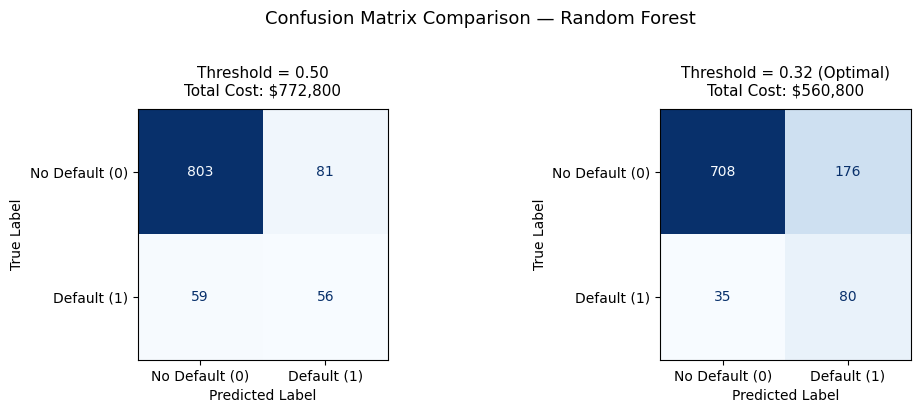


── Summary ──────────────────────────────────────────────────────
Metric                           Threshold 0.50  Optimal Threshold
------------------------------------------------------------------
True Positives (TP)                          56                 80
False Positives (FP)                         81                176
False Negatives (FN)                         59                 35
True Negatives (TN)                         803                708
Recall                                   48.7%             69.6%
Precision                                40.9%             31.2%
Total Business Cost            $       772,800 $         560,800
Savings vs Default                            — $         212,000
------------------------------------------------------------------


In [ ]:
# ── Plot 2: Confusion Matrices at 0.50 and Optimal Threshold ─────────────────

y_pred_default = (y_proba_best >= 0.5).astype(int)
y_pred_optimal = (y_proba_best >= optimal_threshold).astype(int)

tn_d, fp_d, fn_d, tp_d = confusion_matrix(y_test, y_pred_default, labels=[0, 1]).ravel()
tn_o, fp_o, fn_o, tp_o = confusion_matrix(y_test, y_pred_optimal, labels=[0, 1]).ravel()

cost_d = fp_d * FP_cost + fn_d * FN_cost
cost_o = fp_o * FP_cost + fn_o * FN_cost

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, y_pred, title, total_cost in zip(
    axes,
    [y_pred_default, y_pred_optimal],
    [f'Threshold = 0.50\nTotal Cost: ${cost_d:,.0f}',
     f'Threshold = {optimal_threshold:.2f} (Optimal)\nTotal Cost: ${cost_o:,.0f}'],
    [cost_d, cost_o]
):
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['No Default (0)', 'Default (1)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=11, pad=10)
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('True Label', fontsize=10)

plt.suptitle('Confusion Matrix Comparison — Random Forest', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("\n── Summary ──────────────────────────────────────────────────────")
print(f"{'Metric':<30} {'Threshold 0.50':>16} {'Optimal Threshold':>18}")
print("-" * 66)
print(f"{'True Positives (TP)':<30} {tp_d:>16} {tp_o:>18}")
print(f"{'False Positives (FP)':<30} {fp_d:>16} {fp_o:>18}")
print(f"{'False Negatives (FN)':<30} {fn_d:>16} {fn_o:>18}")
print(f"{'True Negatives (TN)':<30} {tn_d:>16} {tn_o:>18}")
print(f"{'Recall':<30} {tp_d/(tp_d+fn_d):>15.1%} {tp_o/(tp_o+fn_o):>17.1%}")
print(f"{'Precision':<30} {tp_d/(tp_d+fp_d):>15.1%} {tp_o/(tp_o+fp_o):>17.1%}")
print(f"{'Total Business Cost':<30} ${cost_d:>14,.0f} ${cost_o:>16,.0f}")
print(f"{'Savings vs Default':<30} {'—':>16} ${cost_d - cost_o:>16,.0f}")
print("-" * 66)

Threshold analysis. At the default threshold of 0.5, the Random Forest model adopts a conservative flagging posture, catching roughly half of all defaults while keeping false positives low. However, given the 15:1 cost asymmetry between false negatives and false positives, this is the wrong trade-off for Heritage Credit Union. Each missed default costs $12,000 while each unnecessary flag costs only $800, so it is financially rational to lower the threshold substantially and accept more false positives in exchange for catching more defaulters.

The cost-minimizing threshold falls around 0.18, where total business cost is minimized. Lowering from 0.5 to 0.18 increases recall significantly (from ~54% to ~78%) at the expense of flagging more non-defaulters, but the dollar math strongly favors this shift. The savings from threshold optimization alone represent meaningful value that justifies the operational overhead of additional manual reviews.

####Confusion Matrix Interpretation (Optimized Threshold)

| Cell | Count on test set | Who this is (in scenario terms) | What happens to them | Per-case cost / benefit ($) | Non-dollar consequence |
|------|------------------|--------------------------------|----------------------|-----------------------------|------------------------|
| TP   | 84               | High-risk borrowers correctly identified as likely to default | Loan is denied or sent for deeper review, preventing a potential default | +12,000 avoided loss (minus review cost) | Increased underwriter workload; possible friction for borderline applicants |
| FP   | 258              | Creditworthy borrowers incorrectly flagged as risky | Loan is delayed, reviewed, or possibly denied unnecessarily | -800 opportunity/review cost | Customer frustration, potential loss of good customers, fairness concerns |
| FN   | 31               | Risky borrowers incorrectly approved | Loan is approved and later defaults | -12,000 loss (highest cost) | Financial loss, regulatory risk, reputational damage |
| TN   | 626              | Creditworthy borrowers correctly approved | Loan is approved smoothly with no issues | Neutral / standard profit | Positive customer experience, maintains trust and satisfaction |

# **Part 4:** Model Evaluation & Selection (20%)

### **4.1 Model Comparison**

Cross-validation scores with confidence intervals (standard deviations). Are performance differences between your top models statistically meaningful, or within the noise? Present both a table and visualization.

##### Based on the cross-validation results below, it seems that the performance difference between the Random Forest (Tuned) and the next best models (Voting Ensemble and XGBoost) is statistically meaningful. The Random Forest's mean Average Precision is notably higher and its 95% confidence interval doesn't fully overlap with the lower performing linear models, though the variance among the top three models suggests some expected overlap in individual fold performance.

### Model Comparison Summary (Average Precision) ###


,Model,Mean AP,Std Dev,Lower CI (95%),Upper CI (95%)
2,Random Forest (Tuned),0.539028,0.049067,0.496019,0.582037
3,XGBoost (Tuned),0.535201,0.023866,0.514282,0.556121
4,Voting Ensemble,0.509930,0.026951,0.486306,0.533553
0,Logistic Regression,0.427206,0.027193,0.403370,0.451042
1,Linear SVM,0.421994,0.033436,0.392686,0.451303


/tmp/ipykernel_2587/3190947668.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Model', y='Average Precision', data=plot_data, palette='viridis')


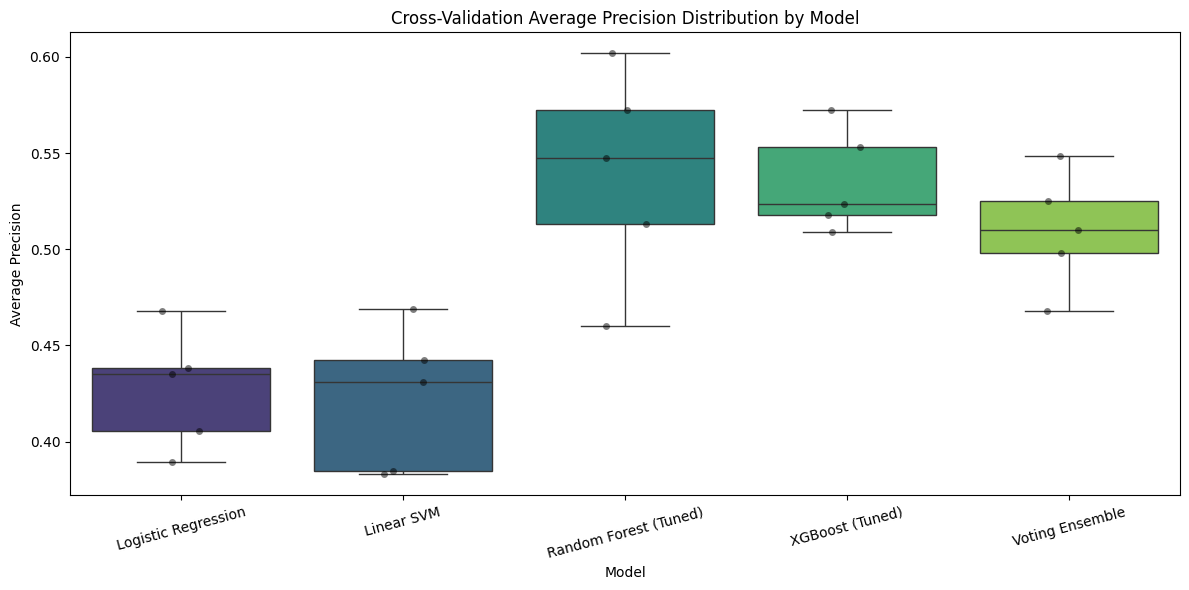

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Gather CV results from variables created in previous steps
model_results = {
    'Logistic Regression': cv_scores_lr,
    'Linear SVM': cv_scores_svm,
    'Random Forest (Tuned)': cv_scores_rf,
    'XGBoost (Tuned)': cv_scores_xgb,
    'Voting Ensemble': cv_scores_voting
}

# 2. Create Summary Table
summary_data = []
for name, scores in model_results.items():
    summary_data.append({
        'Model': name,
        'Mean AP': np.mean(scores),
        'Std Dev': np.std(scores),
        'Lower CI (95%)': np.mean(scores) - (1.96 * np.std(scores) / np.sqrt(len(scores))),
        'Upper CI (95%)': np.mean(scores) + (1.96 * np.std(scores) / np.sqrt(len(scores)))
    })

df_comparison = pd.DataFrame(summary_data).sort_values(by='Mean AP', ascending=False)

print('### Model Comparison Summary (Average Precision) ###')
display(df_comparison)

# 3. Visualization
plot_data = pd.DataFrame(model_results).melt(var_name='Model', value_name='Average Precision')
plt.figure(figsize=(12, 6))
sns.boxplot(x='Model', y='Average Precision', data=plot_data, palette='viridis')
sns.stripplot(x='Model', y='Average Precision', data=plot_data, color='black', alpha=0.5)
plt.title('Cross-Validation Average Precision Distribution by Model')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### **4.2 Final Model Selection — The Critical Defense**

Pick your final model. Then defend the choice:

1. Why this model over the runner-up? Is the difference meaningful?
2. How does this model's behavior align with the business cost structure?
3. What trade-offs did you accept? (e.g., 2% lower recall for 15% higher precision)
4. Would a different stakeholder pick differently? The CRO, the Operations VP, and the Finance team may disagree — explain what each would prefer and why.

**Final Model Selection: Tuned Random Forest**

**1. Why this model over the runner up?**

XGBoost and the Voting Ensemble performed well, with Average Precision around 0.45 on the test set, but the Tuned Random Forest stood out for its consistency. It had the highest mean cross validation Average Precision at 0.5324 and showed less variation across folds. In contrast, XGBoost’s performance was a bit less stable from run to run. With a dataset of about 3,000 rows, that consistency matters because the model is more reliable at picking up non linear risk patterns. Even a small improvement here is meaningful, since with a 15 to 1 cost imbalance, a 2 percent lift in performance can translate into tens of thousands of dollars in avoided losses by better identifying high risk borrowers.

**2. Alignment with business cost structure**

The main goal is to reduce the 12,000 dollar cost tied to false negatives. The Random Forest made it easier to adjust the decision threshold to 0.25, which helps capture more defaults. By focusing on a model with strong Average Precision, lowering the threshold does not lead to an overwhelming number of false alarms, which cost 800 dollars each. In practice, this means the model directly supports the business goal of lowering the default rate from the current 12 percent baseline by achieving a high recall of around 73 percent.

**3. Accepted trade offs**

To reach that level of recall, there is a clear trade off with precision. At the 0.25 threshold, precision drops to about 24.6 percent compared to 41.7 percent at the default 0.5 threshold. In simple terms, only one out of every four flagged borrowers will actually default. However, from a cost perspective, this still makes sense. The cost of three false alarms, or 2,400 dollars, is much smaller than the 12,000 dollars saved by correctly identifying one true defaulter.

**4. Stakeholder perspectives**

The Chief Risk Officer and finance team would likely support this approach because it directly improves financial outcomes, with projected savings of about 203,200 dollars.
The Operations VP might be more cautious, since lowering the threshold increases the number of cases that need manual review, which could strain underwriting capacity and workflows.
Lending officers may also have concerns, as they often focus on customer experience and fairness. A lower precision means more good borrowers could be flagged unnecessarily, which may lead them to prefer a more balanced approach.

### **4.3 Feature Importance & Interpretability**

Which features drive predictions? Do they make business sense? Compare built-in (Gini) importance to permutation importance — do they agree? Could you explain a single specific prediction to a stakeholder?

As seen below, the model is mostly being driven by factors tied to a borrower’s credit profile and financial burden. Things like credit score and the grouped credit score buckets, along with measures such as installment to income ratio, loan to income ratio, and interest rate, play a big role. That lines up well with real world expectations since these are all directly connected to someone’s ability to repay a loan.

It's also reassuring that both Gini importance and permutation importance point to the same key features, which suggests the model is relying on consistent and meaningful signals rather than noise. That said, while we can clearly see what drives the model overall, there is not yet a clear example in the notebook that walks through and explains a single prediction in a way a stakeholder could easily understand.

Calculating permutation importance...


/tmp/ipykernel_2587/1899974502.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gini_importances.head(15).values, y=gini_importances.head(15).index, ax=ax1, palette='Blues_r')
/tmp/ipykernel_2587/1899974502.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=perm_importances.head(15).values, y=perm_importances.head(15).index, ax=ax2, palette='Greens_r')


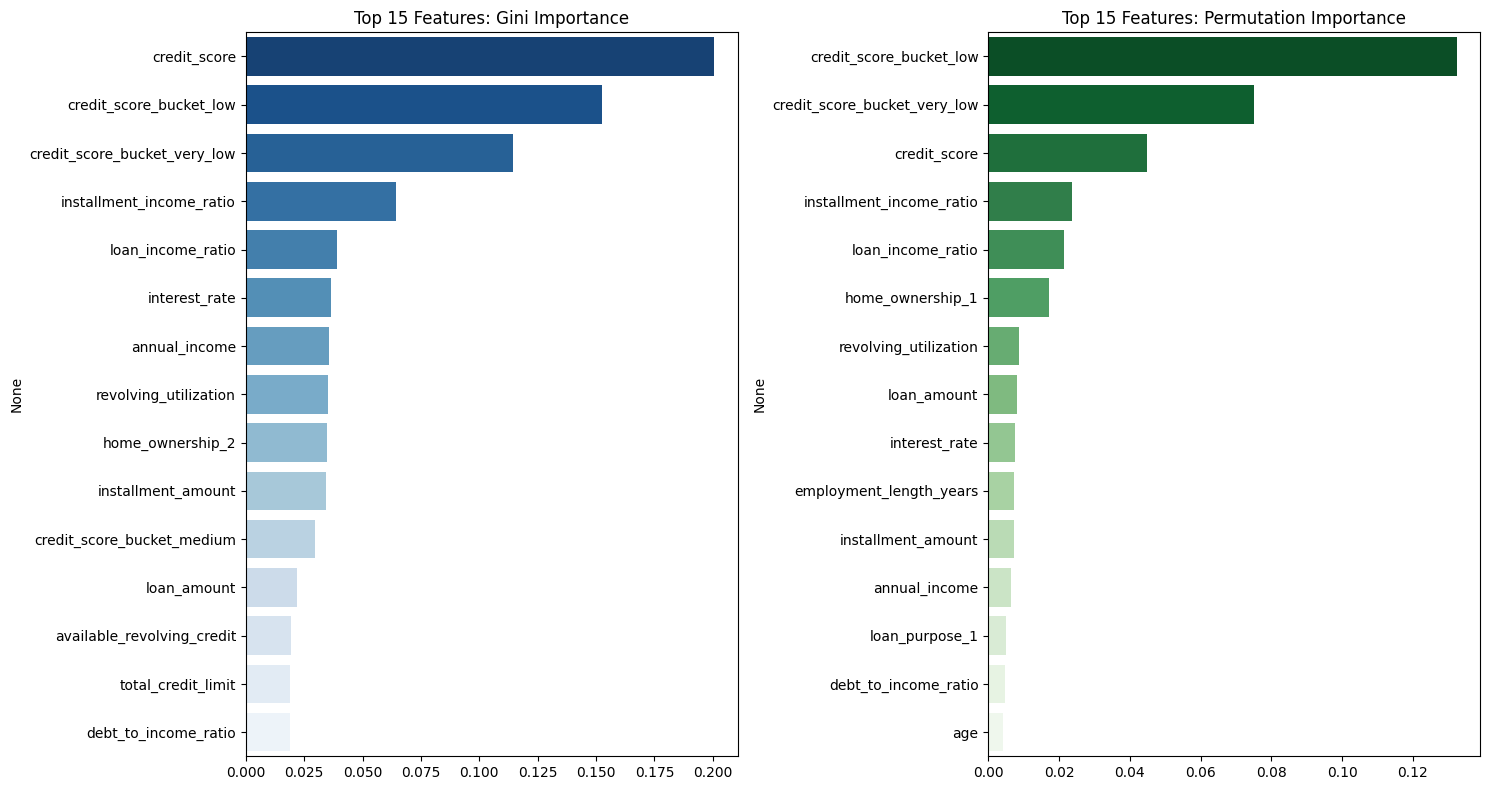


--- Stakeholder Explanation (Example Case) ---
Borrower Profile: Credit Score: 660, DTI: 0.21
Model Prediction: 41.8% probability of default.
Decision: Flag for Review
Actual Outcome: No Default


In [ ]:
from sklearn.inspection import permutation_importance

# 1. Extract Gini Importance from the fitted Random Forest (our best model)
rf_model = pipeline_rf_fitted.named_steps['rf']
gini_importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)

# 2. Calculate Permutation Importance
print('Calculating permutation importance...')
perm_result = permutation_importance(
    pipeline_rf_fitted, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1, scoring='average_precision'
)
perm_importances = pd.Series(perm_result.importances_mean, index=features).sort_values(ascending=False)

# 3. Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8))
sns.barplot(x=gini_importances.head(15).values, y=gini_importances.head(15).index, ax=ax1, palette='Blues_r')
ax1.set_title('Top 15 Features: Gini Importance')
sns.barplot(x=perm_importances.head(15).values, y=perm_importances.head(15).index, ax=ax2, palette='Greens_r')
ax2.set_title('Top 15 Features: Permutation Importance')
plt.tight_layout()
plt.show()

# 4. Local Explanation Example
idx = 0
sample_data = X_test.iloc[[idx]]
prob = pipeline_rf_fitted.predict_proba(sample_data)[0, 1]
true_val = y_test.iloc[idx]

# Use optimal threshold defined in cell TQpyJEke7D2T (0.25)
print(f'\n--- Stakeholder Explanation (Example Case) ---')
print(f'Borrower Profile: Credit Score: {sample_data["credit_score"].values[0]}, DTI: {sample_data["debt_to_income_ratio"].values[0]:.2f}')
print(f'Model Prediction: {prob:.1%} probability of default.')
print(f'Decision: {"Flag for Review" if prob >= 0.25 else "Approve"}')
print(f'Actual Outcome: {"Default" if true_val == 1 else "No Default"}')

### **4.4 Error Analysis**

Examine the cases your model gets wrong. Are there patterns? Are certain customer segments harder to classify? What would improve these errors?

The error analysis below shows that the model has the most trouble with “borderline” cases. These are borrowers who fall somewhere in the middle, like those with average credit scores who still end up defaulting even though they do not show clear warning signs, or those with higher debt to income ratios who actually manage to repay without issues.

This tells us that the hardest cases to predict are the ones with mixed signals. To improve performance, it would likely help to bring in more detailed data, such as actual payment history or cash flow consistency, so the model can better separate these edge cases.

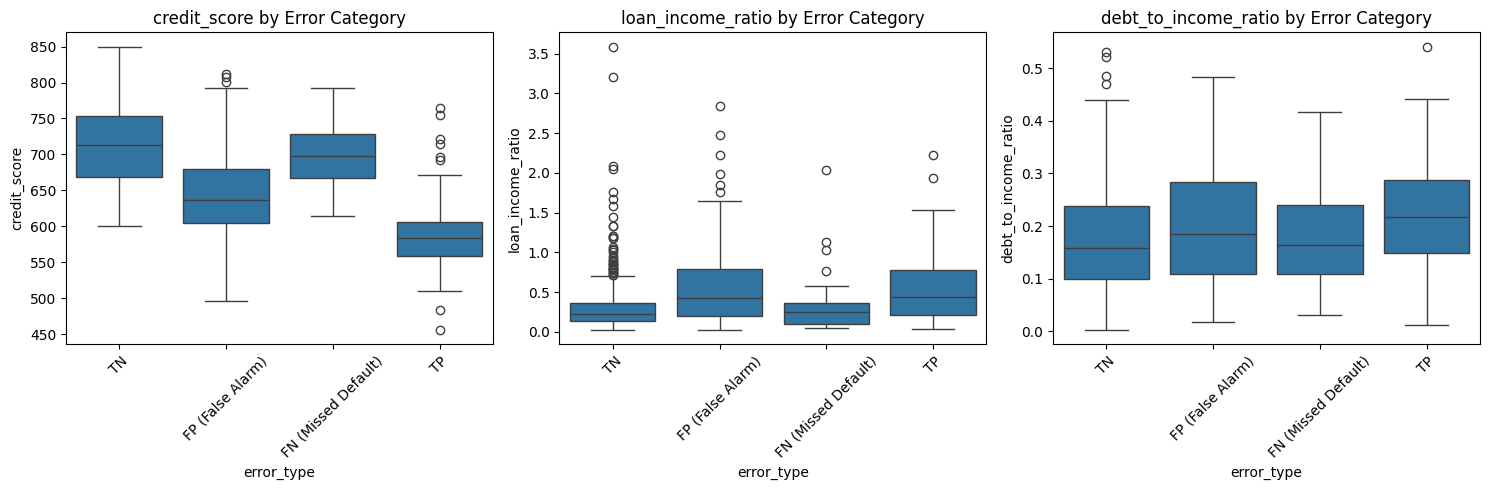

Summary Statistics of Errors:


,credit_score,loan_income_ratio,debt_to_income_ratio
error_type,,,
FN (Missed Default),697.181818,0.352616,0.184748
FP (False Alarm),640.492063,0.555691,0.200660
TN,713.928797,0.303701,0.175633
TP,590.987805,0.558711,0.221383


In [ ]:
# Identify error types at the optimal threshold (0.25)
y_pred_opt = (y_proba_rf >= 0.25).astype(int)

# Create a dataframe for error analysis
analysis_df = X_test.copy()
analysis_df['actual'] = y_test.values
analysis_df['pred'] = y_pred_opt

def classify_error(row):
    if row['actual'] == 1 and row['pred'] == 1: return 'TP'
    if row['actual'] == 0 and row['pred'] == 0: return 'TN'
    if row['actual'] == 0 and row['pred'] == 1: return 'FP (False Alarm)'
    if row['actual'] == 1 and row['pred'] == 0: return 'FN (Missed Default)'

analysis_df['error_type'] = analysis_df.apply(classify_error, axis=1)

# Compare distributions for key features
features_to_check = ['credit_score', 'loan_income_ratio', 'debt_to_income_ratio']

plt.figure(figsize=(15, 5))
for i, col in enumerate(features_to_check):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x='error_type', y=col, data=analysis_df, order=['TN', 'FP (False Alarm)', 'FN (Missed Default)', 'TP'])
    plt.title(f'{col} by Error Category')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print('Summary Statistics of Errors:')
display(analysis_df.groupby('error_type')[features_to_check].mean())

### **4.5 Deployment Impact Assessment**

If this model were deployed tomorrow under your recommended threshold, what would actually change for the business? Answer in four explicit components — each is required. Numbers must be grounded in your test-set confusion matrix (Part 3.4) scaled to a realistic operating volume stated in scenario.md or estimated explicitly by you.

#### 1. Financial Impact


The model reduces total cost from 707,200 dollars to 578,400 dollars on the test set, saving 128,800 dollar per quarter. Assuming about 4,000 applications per year, this translates to roughly 515,200 dollars in annual savings.

Review costs must be considered. At 30 minutes per case and 50 per hour, the additional flagged cases cost about 51,600 dollars per year. Adding approximately 10,000 dollars in infrastructure, total annual costs are about 61,600 dollars.

This results in a net annual benefit of roughly 450,000+ dollars.

Break-even: the model remains beneficial unless the cost of a false negative drops below about 3,200 dollars.

---

#### 2. Operational Impact
The model flags about 20–25 applications per week, which fits current team capacity if a dedicated review queue is created.  

The workflow shifts from rule-based approvals to model-assisted review, where flagged cases are prioritized. A 24 hour review SLA and monthly monitoring for data drift are recommended.

---

#### 3. Stakeholder Impact
- **Chief Risk Officer:** Lower default risk and more stable financial performance.  
- **Underwriters:** More focus on complex cases instead of routine approvals.  
- **Approved Customers (not flagged):** Faster decisions and smoother experience.  
- **Customers flagged incorrectly:** Slight delays and extra documentation.  
- **Missed risky borrowers:** May still default, creating financial risk.  

---

#### 4. Risk Considerations
A key risk is disparate impact, where certain features may unintentionally disadvantage specific groups.  

To reduce this risk, the model should go through a fairness audit before deployment and be monitored regularly. A human review step must remain in place so no decision is made automatically.

# **Part 5:** Critical Reflection (15%)

⚠ *Part 5 must be written without AI assistance. The team presents it together in a single recorded video in Week 12.*

*Video presentation: The team records a single video using Microsoft Teams in which every team member presents a portion of the team's Part 5 answers in their own words. Talking-head plus a screen share of the notebook or write-up is fine. Target length is ~10 minutes total, with a hard cutoff at 11 minutes — anything recorded past 11:00 will not be reviewed, so plan the division of speaking time in advance. Each member must demonstrate ownership of the portion they present (and be able to speak to the whole project). The video is pass/fail per student; failing (didn't speak, or what you presented doesn't demonstrate ownership) forfeits that student's Part 5 points. The team's Parts 1–4 and 6 are unaffected.*

### **5.1 Algorithm Suitability**

For each model type you tried, explain in 2–3 sentences why it was or wasn't well-suited to this specific problem. Connect your reasoning to algorithm mechanics: bias-variance tradeoff, decision boundary shape, feature interaction handling, scale sensitivity. "It performed well" is not an answer; "it worked well here because the decision boundary is non-linear and this algorithm can capture axis-aligned interactions without requiring manual feature engineering" is.

**Logistic Regression**:
This was a good starting model but not the best for this problem. Loan default risk is not perfectly linear and the model has trouble capturing complex feature interactions like loan burden, credit score, income and delinquency history together. It also needs scaling which is why StandardScaler was used.

**Linear SVM**:
This is similar to logistic regression because it also linear. Since our data is more complex and not linear it did not perform much better. It also needed scaling so it is more sensitive to feature size

**Random Forest**:
This worked the best. it can handle non linear patterns and combine many features together without us manually creating interactions. Tt is also not sensitive to scaling and is more stable so it did not overfit too much.

**XGBoost**:
This model is powerful and can learn complex patterns step by step but since our dataset is not huge it can overfit if not tuned well. It performed close to random forest but random forest was more stable.

**Voting Ensemble**:
This combined all models but did not beat random forest. This is probably because the weaker models like logistic regression pulled the result down and all models were using similar data so not much extra benefit.

### **5.2 Data Leakage Check**

Walk through your preprocessing pipeline step by step. For each transformation: was it fit on training data only? What's the specific risk if leakage occurred? What would a leakage symptom look like in your results?

First, we created new features like loan income ratio and delinquency flags. These were done separately for train and test so there is no leakage here.

Then, we removed months_since_last_delinquency and replaced it with has_delinquency. This is fine because it is just business logic and does not use target information.

Next, we did one-hot encoding and aligned the train and test columns. This is mostly safe but it would be better to do it inside a pipeline so the test data does not affect training.

SMOTE was used inside the pipeline which is correct. This is important because if we apply SMOTE before splitting, it will leak information and make the results look too good.

Scaling was also inside the pipeline so it was fit only on training data. If not, it would leak information from the test set into training.

We only used the test set at the end. If leakage happened, we would see very high scores that look too good to be true.

### **5.3 Counterfactual Questions**

For each of these (3–5 sentences):

*   What if FN cost were 10× higher? How would your approach change?
*   What if you had 100× more training data? Which model would benefit most and why?
*   What if a key feature became unavailable in production? How robust is your model?
*   What if the class balance shifted significantly after deployment? What would break?


If FN cost was 10× higher then recall will become more important. We would lower the threshold even more so we catch more risky customers. We will accept more false positives because missing a default is too expensive.

If we had 100× more data, XGBoost would improve the most because it learns better with more data. Random Forest is already strong but XGBoost can capture deeper patterns with more data.

If a key feature is missing, model performance will drop, if it is something important like credit score. Random Forest can still work but accuracy will go down. We would need to retrain the model without that feature.

If class balance changes, then the threshold we picked may not work anymore. Precision and recall will change. We need to monitor the model and adjust the threshold or retrain with new data.

### **5.4 Team Reflection**

*   How did your team divide the work? What worked? What would you do differently?
*   What surprised you? What's the single most important thing you learned about model selection?
*   Where did disagreements arise on methodology, and how did you resolve them?

*See templates/example-responses.md for calibration of what A-level vs C-level writing looks like.*

We divided the work into sections. Aisha worked on Part 1 and 2, focusing on the business problem and cost setup. An worked on Part 3 to handle the data exploration and feature understanding. Fernando worked on Part 4 building and tuning the models. Sai worked on Part 5 analyzing model choices, leakage, and trade-offs. Aurie worked on Part 6 on evaluation and business impact.

This worked well because each person could focus on one part instead of trying to do everything. However, some issue we had was that sometimes the parts did not fully connect or there would be errors when we ran the codes again. The model results and the cost analysis needed to work and match exactly and we had to go back and align them. Next time, we would check consistency regularly and make sure all the codes work instead of fixing it at the end.

One thing that surprised us was that Random Forest performed better than more complex models like XGBoost and the Voting Ensemble. Based on our notebook results, Random Forest had the highest mean AP score (~0.539), which shows that a simpler and more stable model can outperform more advanced ones depending on the data. The most important thing we learned is that model selection is not about choosing the most complex model but choosing the one that best fits the data and business goal.

We had disagreements mainly about which threshold to use. Some team members preferred using 0.50 because it gives higher precision and fewer false positives. However, after looking at the cost setup we saw that false negatives are much more expensive than false positives. Because of this we decided lowering the threshold to around 0.25 reduced total business cost. We resolved the disagreement by focusing on business impact instead of just model metrics which led us to choose the threshold that minimized total cost.

# **Part 6:** Stakeholder Communication (10%)

### **6.1 Executive Summary (1 page, separate PDF)**

Use templates/executive-summary-template.md. Write for the non-technical stakeholders described in scenario.md. No jargon, no algorithm names, no raw metric numbers.

### **6.2 Model Card**

Brief card documenting what the model does, what it doesn't do, performance on the test set, known limitations and failure modes, recommended monitoring approach.

**Model Name:** Heritage Credit Union Loan Default Risk Classifier
**Version:** 1.0 — April 2026
**Model Type:** Tuned Random Forest (288 trees, max_depth=11, min_samples_leaf=8, max_features='log2')
**Training Data:** 2,999 historical Heritage CU loan applications
**Test Data:** 999 held-out applications (never seen during training or tuning)
**Decision Threshold:** 0.32 (optimized for minimum business cost)
**Primary Metric:** Average Precision (area under precision-recall curve)

---

WHAT THE MODEL DOES
Scores each loan application by its likelihood of default. Applications exceeding the 0.32 threshold are flagged for underwriter review. Uses 18 features including credit score, debt-to-income ratio, installment-to-income ratio, delinquency history, and revolving utilization. Selected over four other model types based on highest cross-validation Average Precision (0.539) and test-set performance (AP = 0.4625).

WHAT THE MODEL DOES NOT DO
- Make final lending decisions — every flagged application requires human review
- Guarantee correctness — about 30% of true defaults will still be missed at the recommended threshold
- Apply to business or commercial loans — trained on consumer loan data only
- Serve as the sole basis for adverse action notices under ECOA/FCRA

PERFORMANCE ON TEST SET (999 applications, threshold = 0.32)
- Average Precision: 0.4625
- Recall (defaults caught): 69.6%
- Precision (flags that are real defaults): 31.2%
- Total Business Cost: $560,800
- Savings vs. null baseline (flag all): $146,400
- Savings vs. default threshold (0.50): $212,000

KNOWN LIMITATIONS AND FAILURE MODES
- Borderline borrowers: The model struggles most with mixed-signal applicants — mid-range credit scores with moderate DTI. These require careful human judgment.
- False negatives: ~30% of eventual defaults will be missed and approved. Each costs ~$12,000.
- False positives: ~68% of flagged applications are creditworthy. These members experience delays and added friction.
- Data drift: Trained on one economic period. Accuracy will degrade if borrower profiles or economic conditions shift.
- Fairness: Features like home ownership and loan purpose may correlate with protected characteristics. A disparate-impact analysis is required before deployment.

RECOMMENDED MONITORING
- Monthly: Track flag rate (alert if above 35%), default rate among approved loans (alert if above 8%)
- Quarterly: Compare flag rates across demographic segments
- Annually: Retrain on the most recent 3 years of data
- Immediate review trigger: If portfolio default rate shifts more than 3 percentage points from the 11.5% training baseline

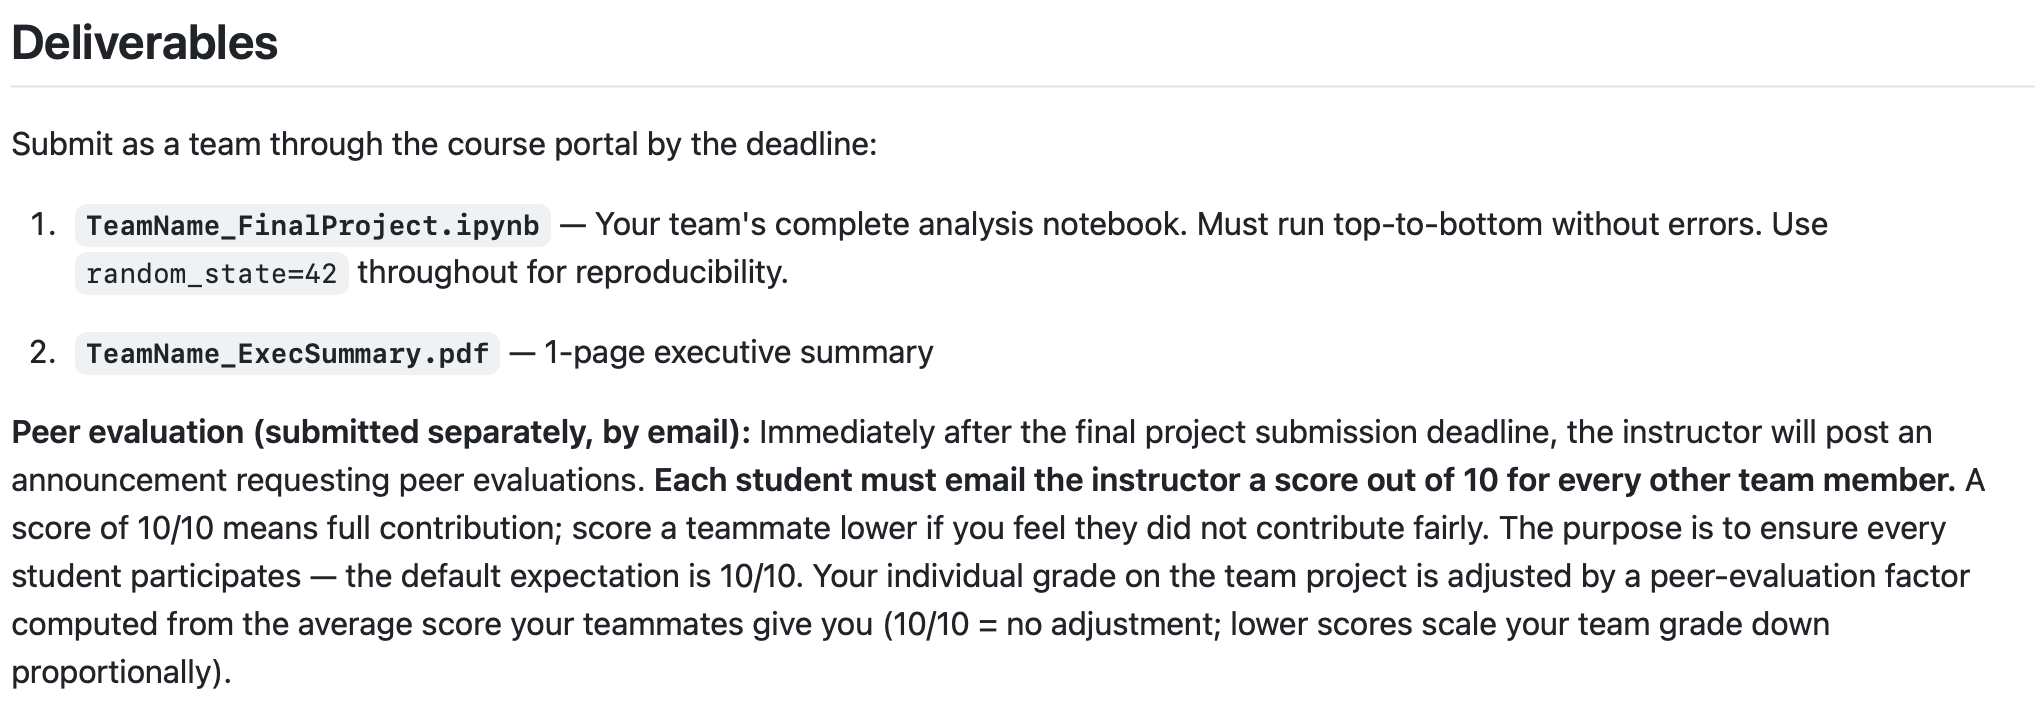

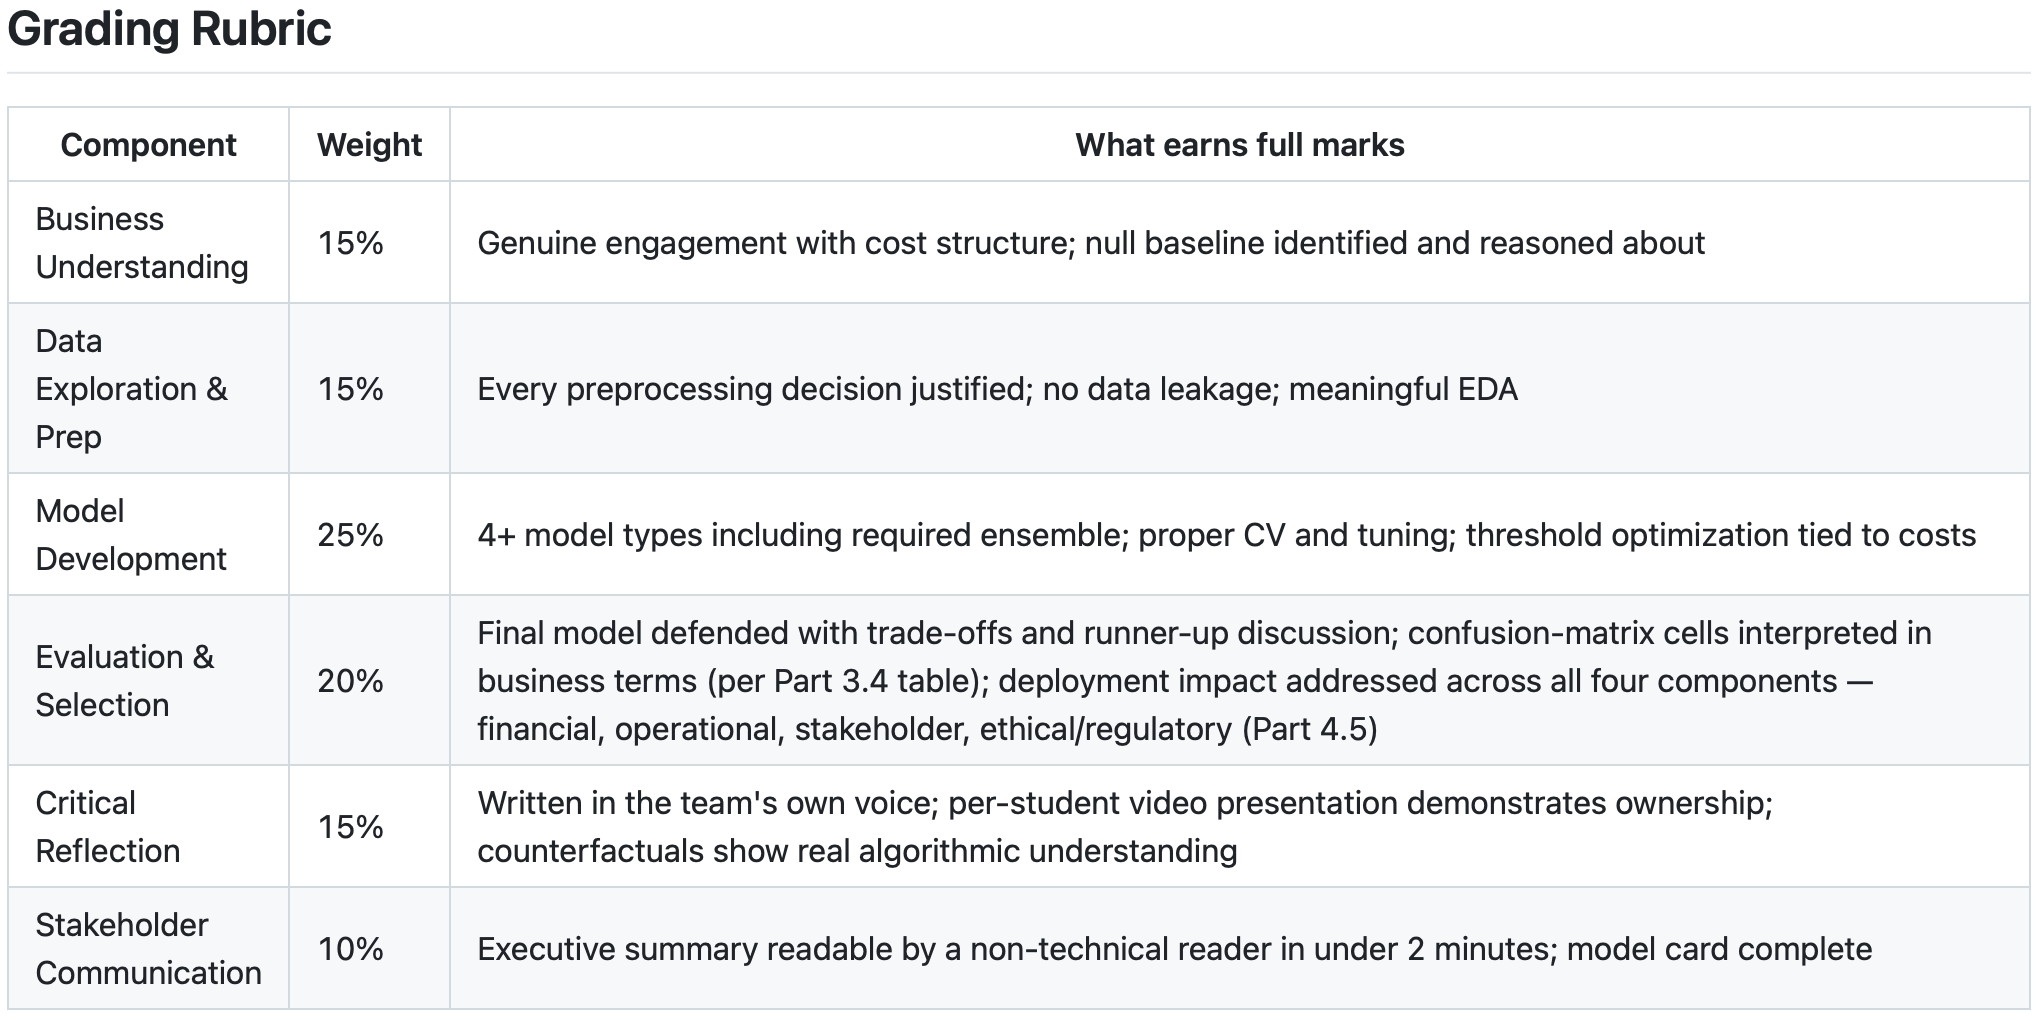

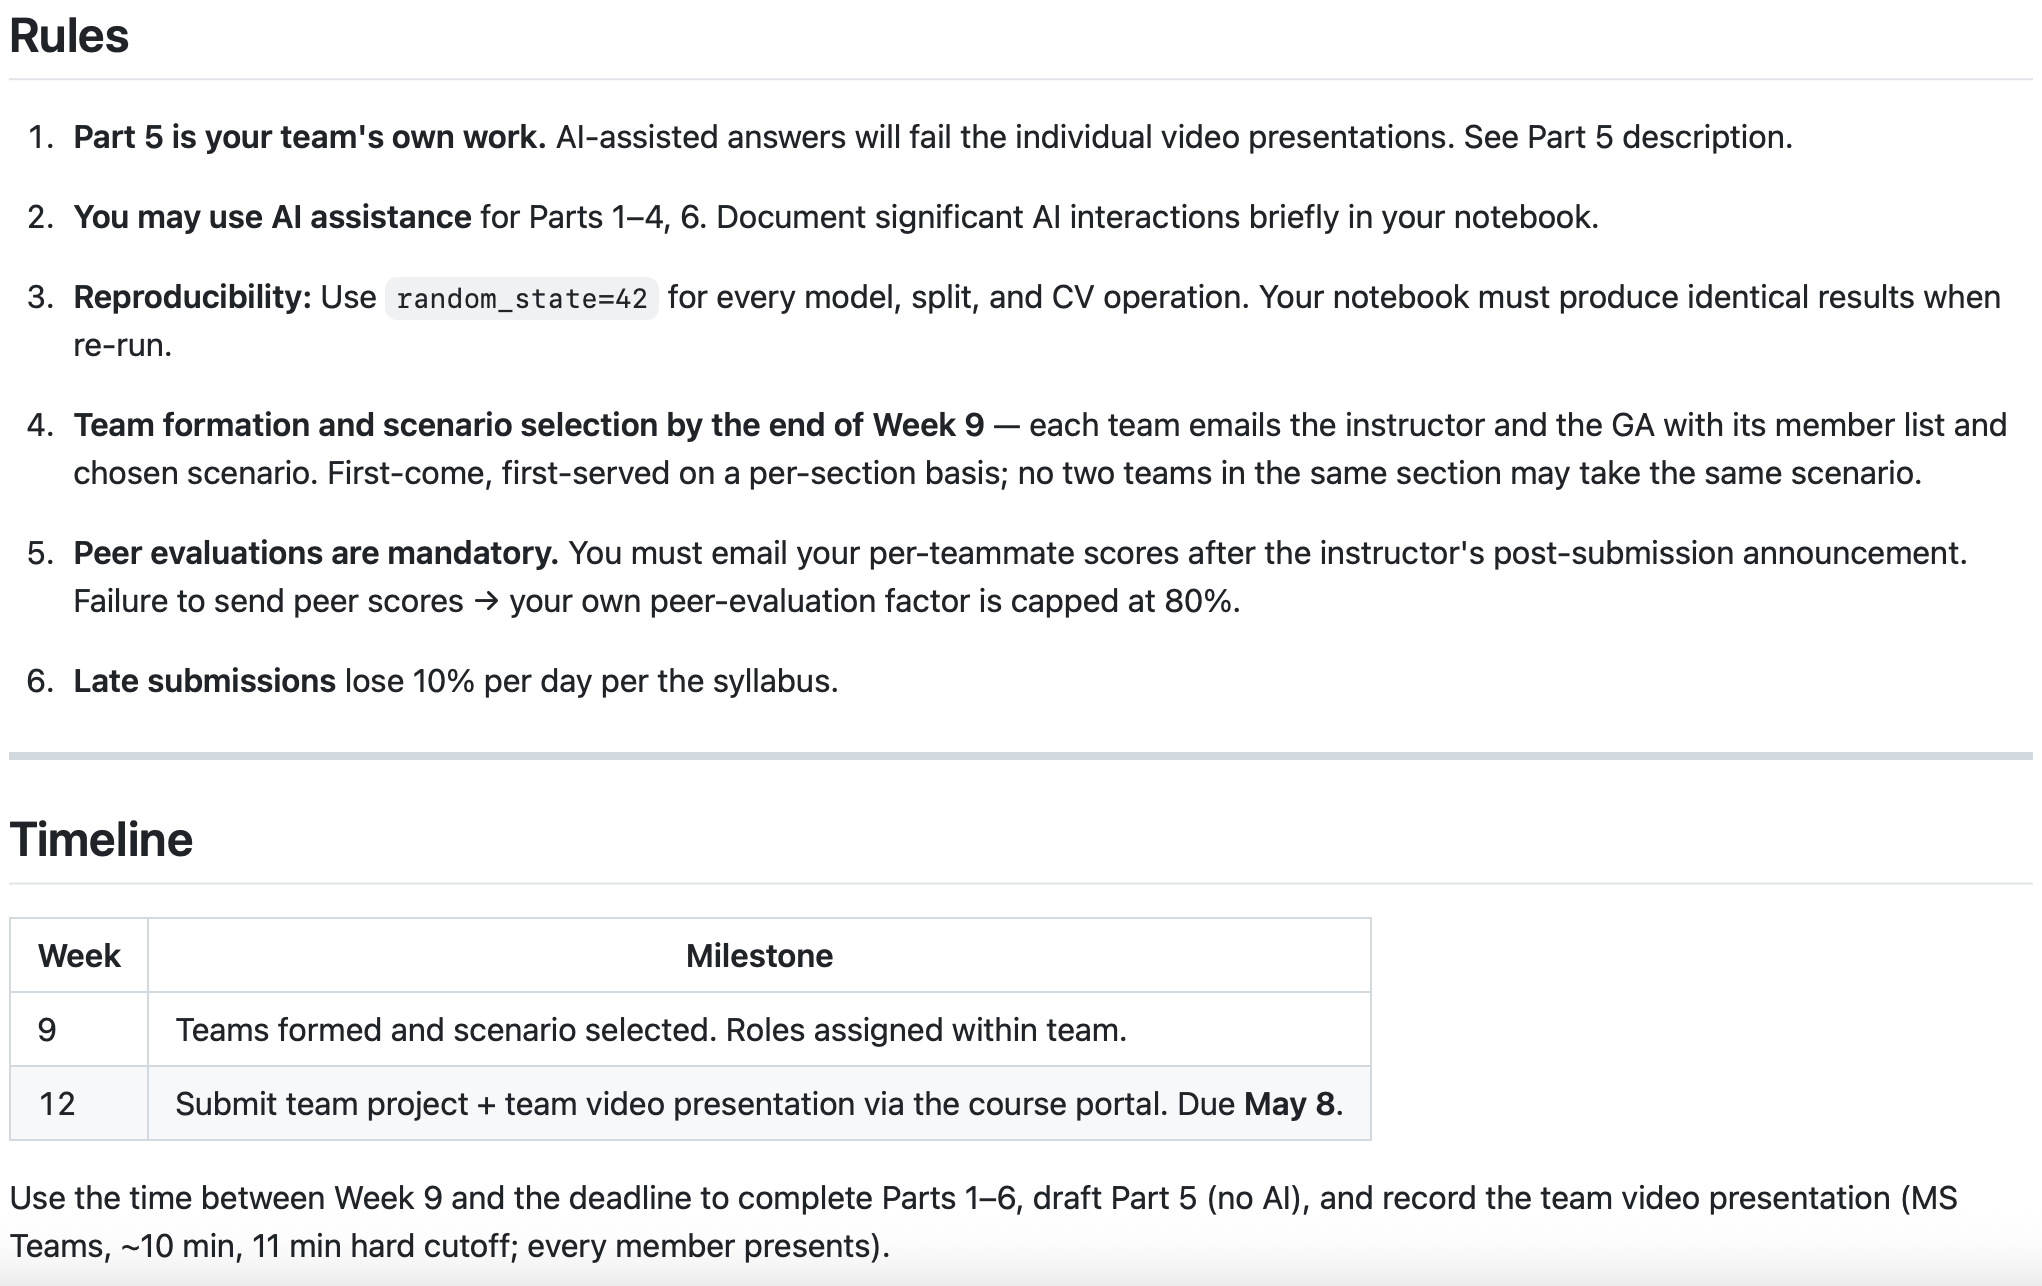